# Xenium Spatial Transcriptomics Analysis

10x Genomics Xenium (single-cell resolution) 종양 데이터에 대한 Niche/Neighborhood 분석 파이프라인.

파이프라인: QC → Annotation → Ligand-Receptor Interaction → Niche → Neighborhood

In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
import spatialdata_io

from src import qc, annotation, lr_interaction, niche, neighborhood

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


## 0. 데이터 로드

Xenium 데이터 경로 지정.

이 서버는 메모리 여유가 크지 않으므로, morphology 이미지(~4.5GB)와 대용량 transcript parquet
로딩은 건너뛰고 세포 단위 발현 테이블(AnnData)만 읽어서 사용한다.

In [2]:
# Xenium 원본 데이터 디렉토리 (10x Xenium Onboard Analysis 출력 폴더)
DATA_DIR = "/data2/projects/2025_heartfailure/spatial_tme/xenium_lung/Xenium_V1_humanLung_Cancer_FFPE"

In [3]:
# 메모리 부담이 큰 요소(형태학 이미지, transcript, 폴리곤/라벨 등)는 모두 끄고
# 세포 x 유전자 발현 테이블(AnnData)만 로드한다.
sdata = spatialdata_io.xenium(
    DATA_DIR,
    cells_boundaries=False,    # 세포 경계 폴리곤 - 이번 분석엔 불필요
    nucleus_boundaries=False,  # 핵 경계 폴리곤 - 이번 분석엔 불필요
    cells_labels=False,        # 세포 라벨 래스터 - 이번 분석엔 불필요
    nucleus_labels=False,      # 핵 라벨 래스터 - 이번 분석엔 불필요
    transcripts=False,         # transcript parquet(수억 행) - 메모리 절약을 위해 스킵
    morphology_mip=False,      # morphology MIP 이미지 - 메모리 절약을 위해 스킵
    morphology_focus=False,    # morphology focus 이미지(~4.5GB) - 메모리 절약을 위해 스킵
    aligned_images=False,      # 정합된 H&E/IF 이미지 - 이번 분석엔 불필요
    cells_table=True,          # 세포 단위 발현 테이블(AnnData) - 필요
    gex_only=False,            # negative control probe/codeword를 var에서 제외하지 않고 유지
)
print(sdata.shapes)

{}


/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


In [4]:
# SpatialData 객체에서 세포 단위 발현 테이블(AnnData)만 꺼내서 이후 QC/분석에 사용
adata = sdata.tables["table"]
print(adata.shape)

(162254, 541)


In [5]:
print(adata.var.columns.tolist())

['gene_ids', 'feature_types', 'genome']


In [6]:

print(adata.var["feature_types"].value_counts())

feature_types
Gene Expression              377
Unassigned Codeword          103
Negative Control Codeword     41
Negative Control Probe        20
Name: count, dtype: int64


In [7]:
# feature_types 분포 확인 후, Gene Expression만 남기기
adata = adata[:, adata.var["feature_types"] == "Gene Expression"].copy()
print(adata.shape)   # (162254, 377) 기대

(162254, 377)


## 1. Quality Control

In [8]:
# Xenium feature matrix에는 실제 유전자 외에 QC용 대조군(negative control) 피처가 함께 들어있다.
#  - Negative Control Probe: 특정 유전자에 매칭되지 않는 프로브. 프로브 자체의 비특이적 배경 신호 추정용.
#  - Negative Control Codeword: 존재하지 않는 코드워드. 광학 디코딩 과정의 배경 신호(오검출) 추정용.
#  - Unassigned Codeword: 패널의 어떤 유전자에도 할당되지 않은 코드워드. 디코딩 노이즈 추정용.
# 이 정보는 h5 로딩 시 gex_only=False로 유지했기 때문에 adata.var["feature_types"]에 남아 있다.
adata.var["is_gene"] = (adata.var["feature_types"] == "Gene Expression").values
adata.var["is_neg_control_probe"] = (adata.var["feature_types"] == "Negative Control Probe").values
adata.var["is_neg_control_codeword"] = (adata.var["feature_types"] == "Negative Control Codeword").values
adata.var["is_unassigned_codeword"] = (adata.var["feature_types"] == "Unassigned Codeword").values

# 이 패널/버전에 실제로 존재하는 대조군 카테고리만 qc_vars로 전달 (없으면 0으로만 채워짐)
qc_vars = [
    col
    for col in ["is_neg_control_probe", "is_neg_control_codeword", "is_unassigned_codeword"]
    if adata.var[col].any()
]

# 세포별 total_counts, n_genes_by_counts 및 qc_vars별 total_counts_*, pct_counts_* 를 계산해 obs에 추가
sc.pp.calculate_qc_metrics(adata, qc_vars=qc_vars, percent_top=None, inplace=True)
adata.obs[["total_counts", "n_genes_by_counts"]].describe()

,total_counts,n_genes_by_counts
count,162254.000000,162254.000000
mean,56.593426,30.201826
std,42.422794,15.080533
min,0.000000,0.000000
25%,27.000000,19.000000
50%,46.000000,29.000000
75%,75.000000,40.000000
max,549.000000,119.000000


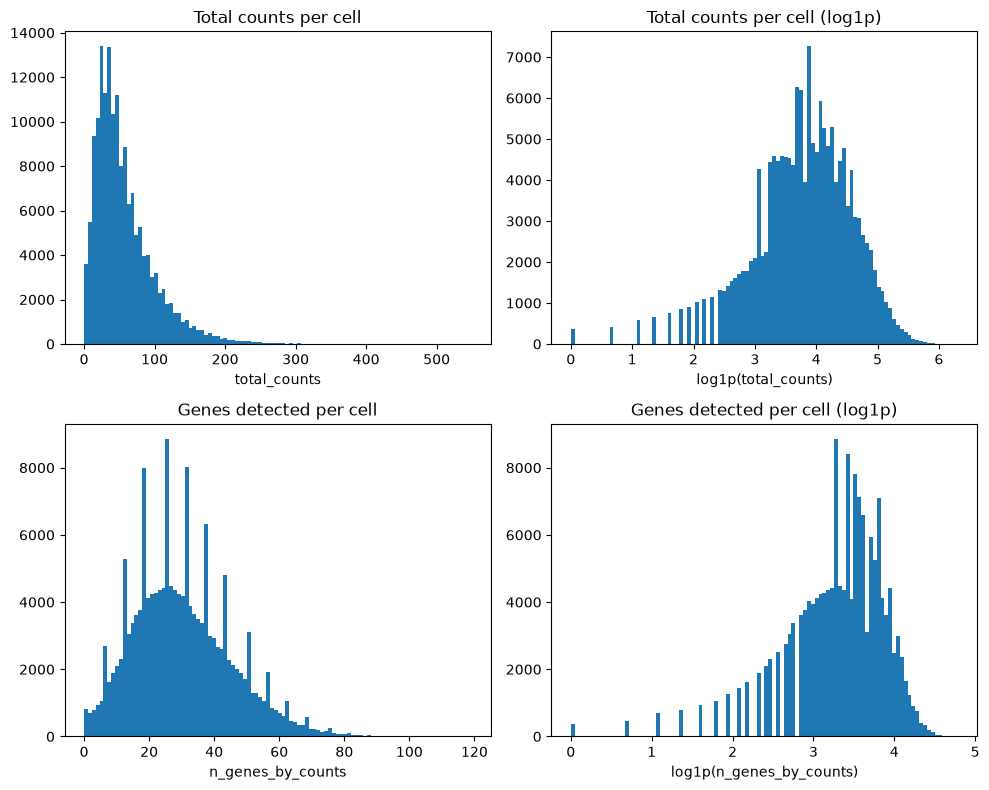

In [9]:
# 세포별 total_counts, n_genes_by_counts 분포 시각화 (선형 스케일 + log1p 스케일)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(adata.obs["total_counts"], bins=100)
axes[0, 0].set_title("Total counts per cell")
axes[0, 0].set_xlabel("total_counts")

axes[0, 1].hist(np.log1p(adata.obs["total_counts"]), bins=100)
axes[0, 1].set_title("Total counts per cell (log1p)")
axes[0, 1].set_xlabel("log1p(total_counts)")

axes[1, 0].hist(adata.obs["n_genes_by_counts"], bins=100)
axes[1, 0].set_title("Genes detected per cell")
axes[1, 0].set_xlabel("n_genes_by_counts")

axes[1, 1].hist(np.log1p(adata.obs["n_genes_by_counts"]), bins=100)
axes[1, 1].set_title("Genes detected per cell (log1p)")
axes[1, 1].set_xlabel("log1p(n_genes_by_counts)")

fig.tight_layout()
plt.show()

In [10]:
# 컷오프(MIN_COUNTS, MIN_GENES) 결정에 참고할 분위수 확인
adata.obs[["total_counts", "n_genes_by_counts"]].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9])

,total_counts,n_genes_by_counts
0.01,3.0,3.0
0.05,10.0,8.0
0.10,15.0,12.0
0.25,27.0,19.0
0.50,46.0,29.0
0.75,75.0,40.0
0.90,112.0,51.0


In [11]:
# Negative control probe/codeword 비율 계산 및 출력 (해당 카테고리가 존재하는 경우만).
# - 셀당 평균/중앙값 비율: calculate_qc_metrics가 만든 pct_counts_<flag> (셀별 %) 기준
# - 데이터셋 전체 비율: 전체 카운트 합산 기준 (var 단위 total_counts 합)
if qc_vars:
    total_counts_all = adata.var["total_counts"].sum()
    for col in qc_vars:
        pct_col = f"pct_counts_{col}"
        ctrl_total = adata.var.loc[adata.var[col], "total_counts"].sum()
        dataset_ratio = 100 * ctrl_total / total_counts_all
        print(
            f"[{col}] 셀당 평균 비율: {adata.obs[pct_col].mean():.4f}%, "
            f"중앙값: {adata.obs[pct_col].median():.4f}%, "
            f"데이터셋 전체 비율: {dataset_ratio:.4f}%"
        )
else:
    print("이 데이터에는 negative control probe/codeword 카테고리가 없습니다.")

이 데이터에는 negative control probe/codeword 카테고리가 없습니다.


### 저품질 세포 필터링

In [12]:
# 저품질 세포 필터링 컷오프.
# squidpy 공식 Xenium 튜토리얼
# (https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_xenium.html)은
# sc.pp.filter_cells(adata, min_counts=10) 를 기본 컷오프로 사용한다.
# Xenium은 타깃 패널(이 데이터는 유전자 377개)만 측정하므로 scRNA-seq 대비
# 세포당 총 카운트/검출 유전자 수 자체가 훨씬 낮게 나오는 것이 정상이며,
# 그만큼 컷오프도 낮게 잡는 것이 튜토리얼의 기본 가정이다.
# 위 히스토그램/분위수 결과를 보고 이 값이 이 데이터 분포에 비해 너무 관대하거나
# 너무 엄격하면 아래 두 값을 조정한다.
MIN_COUNTS = 10   # 원 데이터셋 처리 기준: >10 transcripts
MIN_GENES = 5     # 원 데이터셋 처리 기준: >5 unique genes

n_cells_before = adata.n_obs
cell_mask = (adata.obs["total_counts"] >= MIN_COUNTS) & (adata.obs["n_genes_by_counts"] >= MIN_GENES)
adata = adata[cell_mask].copy()

print(f"필터링 전: {n_cells_before}개 세포")
print(f"필터링 후: {adata.n_obs}개 세포 ({adata.n_obs / n_cells_before:.1%} 유지)")

필터링 전: 162254개 세포
필터링 후: 154469개 세포 (95.2% 유지)


### Normalization & log1p

In [13]:
# 원본 카운트 보관 (일부 하위 분석이 raw count를 요구할 수 있음)
adata.layers["counts"] = adata.X.copy()

In [14]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
print(adata)

AnnData object with n_obs × n_vars = 154469 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'is_gene', 'is_neg_control_probe', 'is_neg_control_codeword', 'is_unassigned_codeword', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs', 'log1p'
    obsm: 'spatial'
    layers: 'counts'


In [15]:
print(adata.X.max()) # 로그 변환 후라 원래 549 → 훨씬 작은 값이어야 정상

3.3945084


### 2-1. Dimensionality Reduction & Clustering (PCA → Neighbors → Leiden → UMAP)

In [16]:
# Xenium은 377개 유전자로 구성된 타깃 패널이므로(전장 transcriptome이 아님) HVG 선택 없이
# 전체 유전자를 사용해 PCA를 수행한다. n_comps는 관례적인 50과 (유전자 수 - 1) 중 작은 값 사용.
N_COMPS = min(50, adata.n_vars - 1)
sc.pp.pca(adata, n_comps=N_COMPS)
print(f"PCA 완료: n_comps={N_COMPS}")
# 예상 소요 시간: 154,469 세포 x 377 유전자 규모에서는 수십 초 이내 (가벼운 연산)

PCA 완료: n_comps=50


In [17]:
# PCA 결과(50 PC) 기반 kNN 그래프 생성. 이후 Leiden 클러스터링과 UMAP의 입력이 된다.
# 예상 소요 시간: 154,469 세포 규모에서 약 2~5분 (서버 CPU/부하 상황에 따라 변동)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=N_COMPS)

In [18]:
# Leiden 클러스터링 resolution. 클러스터가 너무 세분화되면 낮추고(예: 0.5~0.8),
# 너무 뭉뚱그려지면 높인다(예: 1.2~1.5). 필요 시 이 값만 조정 후 재실행하면 됨.
LEIDEN_RES = 1.0

# flavor="igraph", n_iterations=2, directed=False는 scanpy가 권장하는 최신 설정
# (기존 기본값인 flavor="leidenalg"는 향후 deprecated 예정).
# 예상 소요 시간: 154,469 세포 규모에서 약 3~8분 (resolution·그래프 밀도에 따라 변동)
sc.tl.leiden(
    adata,
    resolution=LEIDEN_RES,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)
print(adata.obs["leiden"].value_counts())

leiden
9     29623
7     25359
8     19408
0     18198
5     16332
2     11557
10    11123
6      8334
3      4856
13     2870
12     2368
11     1968
1      1369
4      1104
Name: count, dtype: int64


In [19]:
# UMAP 임베딩. neighbors 그래프가 이미 계산되어 있어야 함.
# 예상 소요 시간: 154,469 세포 규모에서 약 3~7분 (이 단계가 지금까지 중 가장 오래 걸릴 수 있음)
sc.tl.umap(adata)

### 2-2. 시각화: UMAP + 공간 분포

In [20]:
adata.obs["leiden"].nunique()

14

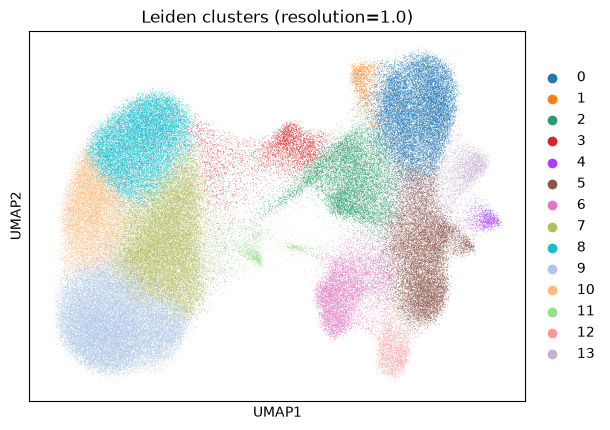

In [21]:
# UMAP에 Leiden 클러스터를 색칠하여 클러스터 분리도를 확인
sc.pl.umap(adata, color="leiden", title=f"Leiden clusters (resolution={LEIDEN_RES})")

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


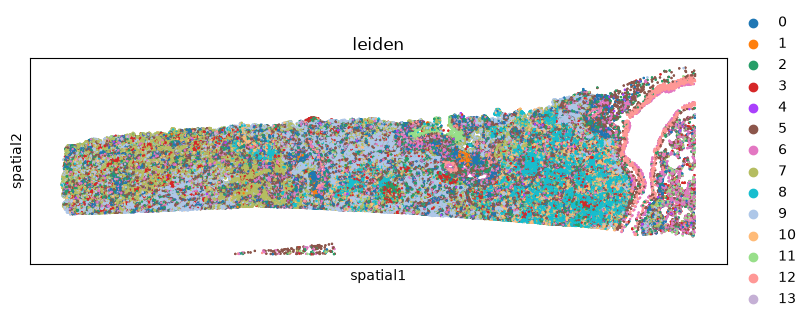

In [22]:
# 실제 공간 좌표(adata.obsm["spatial"])에 동일한 Leiden 클러스터를 뿌려 공간 분포 확인.
# morphology 이미지를 로드하지 않았으므로 img=False, 세포 수가 많아 shape=None(점 표시)과
# 작은 size로 렌더링 부담을 줄인다.
sq.pl.spatial_scatter(
    adata,
    color="leiden",
    shape=None,
    size=2,
    img=False,
    figsize=(8, 8),
)

## 2. Cell-Type Annotation

### 2-1. 클러스터별 차별발현유전자(DEG) 탐색 (Wilcoxon)

leiden 클러스터를 아직 세포유형으로 명명하지 않은 상태에서, 클러스터별로 어떤 유전자가
특이적으로 발현되는지 먼저 데이터 기반으로 확인한다. 정규화·log1p된 `adata.X`를 사용한다.

In [23]:
# 클러스터(leiden)별 차별발현유전자(marker) 탐색 - Wilcoxon rank-sum test
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

### 2-2. 클러스터별 상위 마커 확인

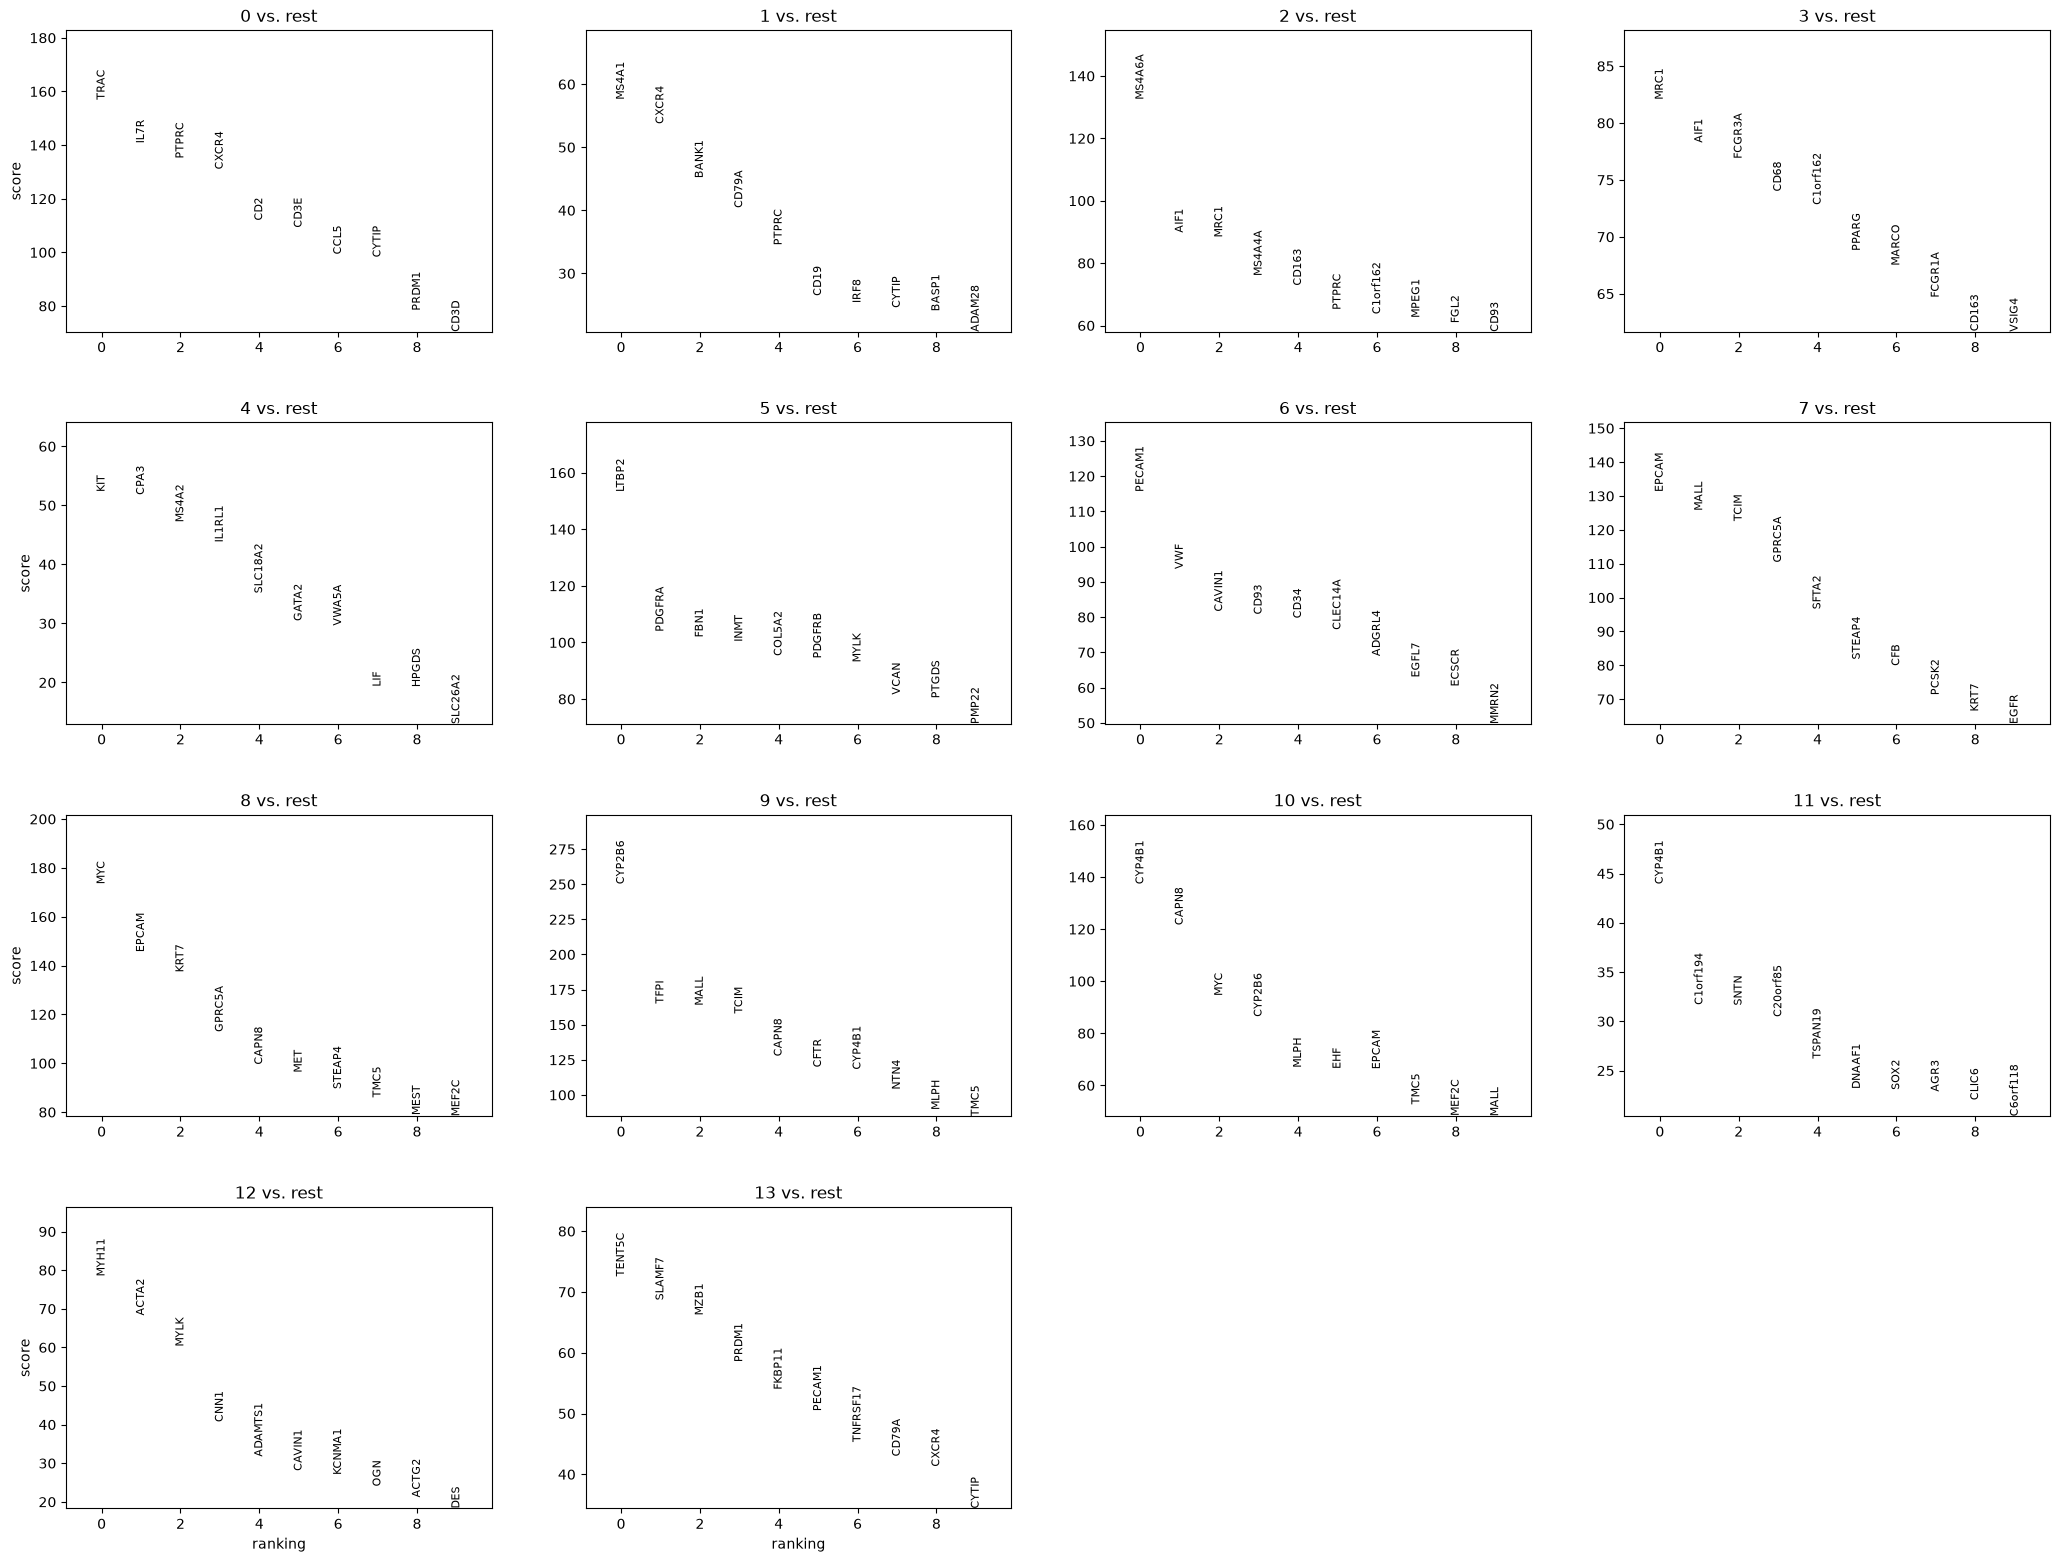

In [24]:
# 클러스터별 상위 마커 유전자 시각화 (클러스터당 상위 10개, z-score 기준)
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [25]:
import pandas as pd

# 클러스터별 top 10 마커를 데이터프레임으로 정리 (컬럼=클러스터, 값=유전자명, score 내림차순)
N_TOP_MARKERS = 10
cluster_order = adata.obs["leiden"].cat.categories
top_markers_df = pd.DataFrame(
    {cl: adata.uns["rank_genes_groups"]["names"][cl][:N_TOP_MARKERS] for cl in cluster_order}
)
top_markers_df.index = [f"top_{i + 1}" for i in range(N_TOP_MARKERS)]
top_markers_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
top_1,TRAC,MS4A1,MS4A6A,MRC1,KIT,LTBP2,PECAM1,EPCAM,MYC,CYP2B6,CYP4B1,CYP4B1,MYH11,TENT5C
top_2,IL7R,CXCR4,AIF1,AIF1,CPA3,PDGFRA,VWF,MALL,EPCAM,TFPI,CAPN8,C1orf194,ACTA2,SLAMF7
top_3,PTPRC,BANK1,MRC1,FCGR3A,MS4A2,FBN1,CAVIN1,TCIM,KRT7,MALL,MYC,SNTN,MYLK,MZB1
top_4,CXCR4,CD79A,MS4A4A,CD68,IL1RL1,INMT,CD93,GPRC5A,GPRC5A,TCIM,CYP2B6,C20orf85,CNN1,PRDM1
top_5,CD2,PTPRC,CD163,C1orf162,SLC18A2,COL5A2,CD34,SFTA2,CAPN8,CAPN8,MLPH,TSPAN19,ADAMTS1,FKBP11
top_6,CD3E,CD19,PTPRC,PPARG,GATA2,PDGFRB,CLEC14A,STEAP4,MET,CFTR,EHF,DNAAF1,CAVIN1,PECAM1
top_7,CCL5,IRF8,C1orf162,MARCO,VWA5A,MYLK,ADGRL4,CFB,STEAP4,CYP4B1,EPCAM,SOX2,KCNMA1,TNFRSF17
top_8,CYTIP,CYTIP,MPEG1,FCGR1A,LIF,VCAN,EGFL7,PCSK2,TMC5,NTN4,TMC5,AGR3,OGN,CD79A
top_9,PRDM1,BASP1,FGL2,CD163,HPGDS,PTGDS,ECSCR,KRT7,MEST,MLPH,MEF2C,CLIC6,ACTG2,CXCR4
top_10,CD3D,ADAM28,CD93,VSIG4,SLC26A2,PMP22,MMRN2,EGFR,MEF2C,TMC5,MALL,C6orf118,DES,CYTIP


### 2-3. 클러스터별 마커 발현 패턴 (Dotplot, DEG 기반)

위에서 찾은 클러스터별 top DEG를 모아(중복 제거) dotplot으로 발현 패턴을 한눈에 확인한다.

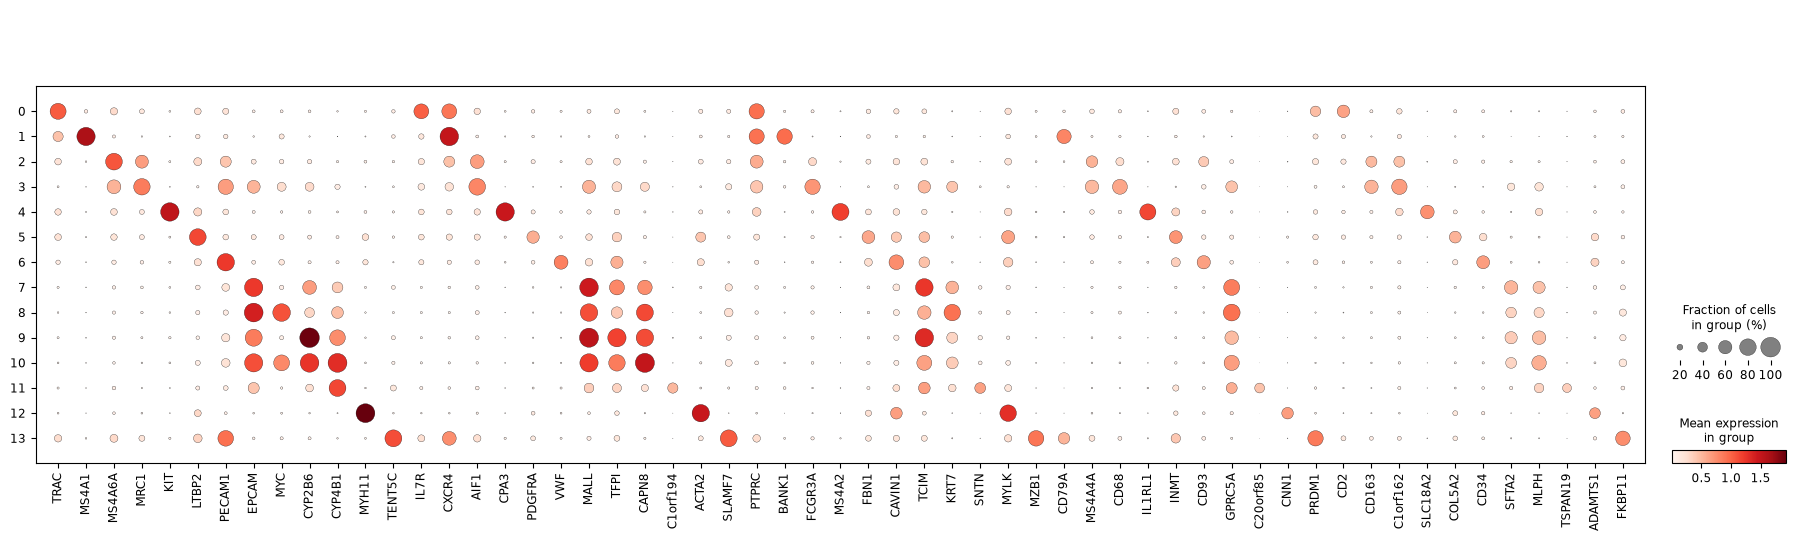

In [26]:
# 클러스터별 top marker(중복 제거)를 모아 dotplot으로 발현 패턴 확인
N_DOTPLOT_MARKERS = 5
top_marker_genes = pd.unique(
    pd.DataFrame(
        {cl: adata.uns["rank_genes_groups"]["names"][cl][:N_DOTPLOT_MARKERS] for cl in cluster_order}
    ).values.ravel()
).tolist()

sc.pl.dotplot(adata, var_names=top_marker_genes, groupby="leiden")

### 2-4. 폐 선암 조직 주요 세포유형별 대표 마커 정의 (패널 존재 여부 필터링)

폐 선암(lung adenocarcinoma) 조직에서 기대되는 주요 세포 유형별 대표 마커 후보를 정의한다.
클러스터에 최종 이름을 붙이는 것은 아래 마커 발현을 직접 보고 판단하며, 여기서는 후보군만 준비한다.

이 데이터의 Xenium 패널(Human Multi-Tissue and Cancer, 377 genes)에 실제로 존재하는
유전자만 남기도록 `adata.var_names`와 대조해서 필터링한다.

Epithelial/Tumor, Smooth muscle/Pericyte, Macrophage/Myeloid는 이 타깃 패널의 마커만으로는
세부 구분(정상 상피 vs 종양, 평활근 vs 주피세포, 대식세포 vs 단핵구 등)이 어려워 상위 계통으로
묶었다.

In [27]:
CANDIDATE_MARKER_DICT = {
    "Epithelial/Tumor": ["EPCAM", "KRT7", "SFTA2", "AGER", "SCGB2A1", "FOXJ1", "EGFR", "ERBB2"],
    "Fibroblast": ["PDGFRA", "COL5A2", "FBLN1", "SFRP2", "DPT", "PCOLCE"],
    "Endothelial": ["PECAM1", "VWF", "CLEC14A", "EGFL7", "RAMP2", "ERG"],
    "Smooth muscle/Pericyte": ["ACTA2", "MYH11", "PDGFRB", "CNN1", "HIGD1B"],
    "T cell": ["CD3D", "CD3E", "CD2", "TRAC", "CD8A", "CD4"],
    "B cell": ["MS4A1", "CD79A", "CD19", "BANK1"],
    "Plasma cell": ["MZB1", "DERL3", "TNFRSF17", "FKBP11"],
    "Macrophage/Myeloid": ["CD68", "CD163", "MARCO", "MRC1", "CD14", "AIF1"],
    "Dendritic cell": ["CD1C", "FCER1A", "CLEC10A", "LILRA4"],
    "Mast cell": ["CPA3", "MS4A2", "KIT"],
    "NK cell": ["GNLY", "NKG7", "KLRD1", "GZMB", "PRF1"],
}

# 패널(adata.var_names)에 존재하는 마커만 남기기
marker_dict = {}
for cell_type, genes in CANDIDATE_MARKER_DICT.items():
    present = [g for g in genes if g in adata.var_names]
    missing = [g for g in genes if g not in adata.var_names]
    if missing:
        print(f"[{cell_type}] 패널에 없어 제외됨: {missing}")
    marker_dict[cell_type] = present

marker_dict

{'Epithelial/Tumor': ['EPCAM',
  'KRT7',
  'SFTA2',
  'AGER',
  'SCGB2A1',
  'FOXJ1',
  'EGFR',
  'ERBB2'],
 'Fibroblast': ['PDGFRA', 'COL5A2', 'FBLN1', 'SFRP2', 'DPT', 'PCOLCE'],
 'Endothelial': ['PECAM1', 'VWF', 'CLEC14A', 'EGFL7', 'RAMP2', 'ERG'],
 'Smooth muscle/Pericyte': ['ACTA2', 'MYH11', 'PDGFRB', 'CNN1', 'HIGD1B'],
 'T cell': ['CD3D', 'CD3E', 'CD2', 'TRAC', 'CD8A', 'CD4'],
 'B cell': ['MS4A1', 'CD79A', 'CD19', 'BANK1'],
 'Plasma cell': ['MZB1', 'DERL3', 'TNFRSF17', 'FKBP11'],
 'Macrophage/Myeloid': ['CD68', 'CD163', 'MARCO', 'MRC1', 'CD14', 'AIF1'],
 'Dendritic cell': ['CD1C', 'FCER1A', 'CLEC10A', 'LILRA4'],
 'Mast cell': ['CPA3', 'MS4A2', 'KIT'],
 'NK cell': ['GNLY', 'NKG7', 'KLRD1', 'GZMB', 'PRF1']}

### 2-5. 세포유형 마커 dotplot (사전 지식 기반)

위 `marker_dict`(패널에 존재하는 마커만)를 이용해 클러스터별 발현 패턴을 확인한다.
이 결과를 보고 각 leiden 클러스터의 세포유형을 직접 판단한다(최종 명명은 아직 하지 않음).

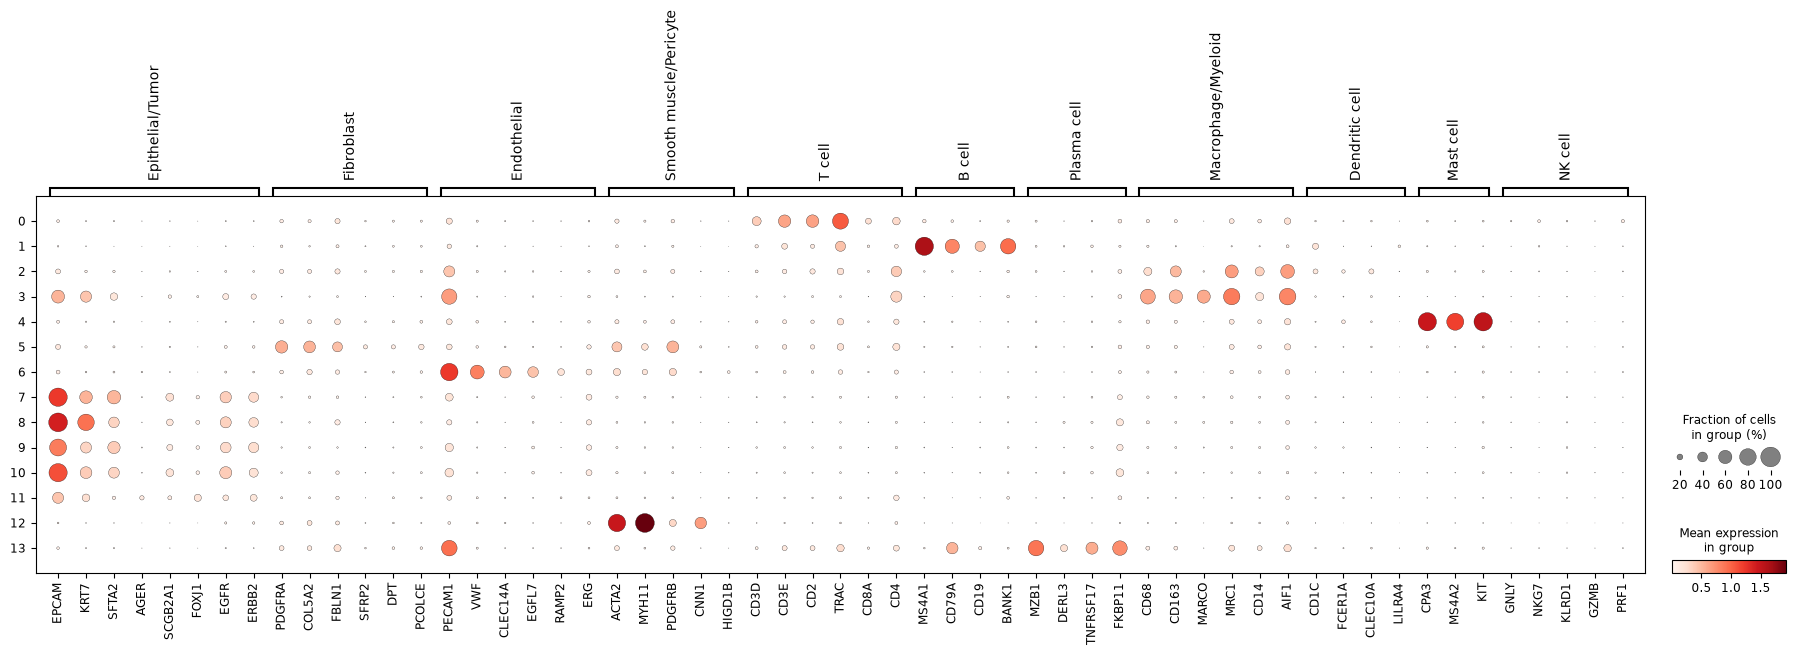

In [28]:
sc.pl.dotplot(adata, var_names=marker_dict, groupby="leiden")

### 2-6. 클러스터 세포유형 최종 판정 및 매핑

2-2 top DEG와 2-5 marker dotplot을 근거로 각 leiden 클러스터에 세포유형을 부여한다.
Macrophage/Myeloid(2, 3)와 Epithelial/Tumor(7, 8, 9, 10, 11)는 마커 조합에 따라 아형으로 세분화했다.

※ 이 377유전자 타깃 패널만으로는 종양세포와 정상 상피를 확정적으로 구분할 수 없다.
MYC/MET 상위 발현을 근거로 한 "Tumor epithelial" 라벨은 잠정적 판단이며, 필요 시 CNV 추론
등으로 추가 검증이 필요하다.

In [29]:
# leiden 클러스터 -> 세포유형 매핑
# - 2, 3: Macrophage/Myeloid를 MARCO/PPARG 유무로 세분화
#   (2: 범용 골수계/단핵구성 마커만 상위, 3: MARCO/PPARG/VSIG4 등 폐포대식세포 특이 마커 상위)
# - 7, 8, 9, 10, 11: Epithelial/Tumor를 top DEG 조합으로 세분화
#   (8, 10: MYC/MET 등 오코진 상위 발현 -> 종양세포 가능성, 9: CYP2B6/CFTR -> 정상형 기도상피,
#    11: SNTN/DNAAF1 등 cilia 유전자 -> 섬모상피세포)
CLUSTER_TO_CELLTYPE = {
    "0": "T cell",
    "1": "B cell",
    "2": "Monocyte/Interstitial macrophage",
    "3": "Alveolar macrophage",
    "4": "Mast cell",
    "5": "Fibroblast",
    "6": "Endothelial",
    "7": "Epithelial/Tumor (GPRC5A+)",
    "8": "Tumor epithelial (MYC+/MET+)",
    "9": "Airway epithelial (CYP2B6+/CFTR+)",
    "10": "Tumor epithelial (MYC+/CYP4B1+)",
    "11": "Ciliated epithelial",
    "12": "Smooth muscle/Pericyte",
    "13": "Plasma cell",
}

adata.obs["cell_type"] = adata.obs["leiden"].map(CLUSTER_TO_CELLTYPE).astype("category")
adata.obs["cell_type"].value_counts()

cell_type
Airway epithelial (CYP2B6+/CFTR+)    29623
Epithelial/Tumor (GPRC5A+)           25359
Tumor epithelial (MYC+/MET+)         19408
T cell                               18198
Fibroblast                           16332
Monocyte/Interstitial macrophage     11557
Tumor epithelial (MYC+/CYP4B1+)      11123
Endothelial                           8334
Alveolar macrophage                   4856
Plasma cell                           2870
Smooth muscle/Pericyte                2368
Ciliated epithelial                   1968
B cell                                1369
Mast cell                             1104
Name: count, dtype: int64

### 2-7. 세포유형 카테고리 팔레트

14개 세포유형을 구분할 색상 팔레트를 정의한다. OKLCH 색공간에서 균등한 색조로 후보를 생성한 뒤,
색각이상(protanopia/deuteranopia/tritanopia) 시뮬레이션 기준으로 인접 카테고리 간 최소 대비(ΔE)가
최대가 되도록 순서를 최적화했다(라이트 배경 대비·명도·채도 기준 모두 통과, 인접 ΔE 최솟값 38.3).
이후 UMAP/공간 지도/막대그래프에서 항상 이 고정된 순서·색상을 사용한다(카테고리마다 색이 바뀌지 않도록).

In [30]:
# 세포유형 표시 순서(고정) + 검증된 카테고리 팔레트.
# 순서를 고정해서 여러 플롯에서 동일 세포유형이 항상 같은 색으로 보이도록 한다.
CELL_TYPE_ORDER = [
    "Tumor epithelial (MYC+/MET+)",
    "Tumor epithelial (MYC+/CYP4B1+)",
    "Epithelial/Tumor (GPRC5A+)",
    "Airway epithelial (CYP2B6+/CFTR+)",
    "Ciliated epithelial",
    "Fibroblast",
    "Endothelial",
    "Smooth muscle/Pericyte",
    "T cell",
    "B cell",
    "Plasma cell",
    "Alveolar macrophage",
    "Monocyte/Interstitial macrophage",
    "Mast cell",
]
CELL_TYPE_PALETTE = dict(zip(CELL_TYPE_ORDER, [
    "#009f89", "#968800", "#0093c8", "#cb625a", "#4e87d6", "#b37900", "#009cad",
    "#c46b2e", "#7c79d4", "#c66083", "#6d9532", "#b664a7", "#309d60", "#9d6dc4",
]))

adata.obs["cell_type"] = adata.obs["cell_type"].cat.reorder_categories(CELL_TYPE_ORDER)

# squidpy(sq.pl.spatial_scatter)는 palette로 dict를 받지 못하고 문자열 컬러맵/ListedColormap만
# 지원하므로, adata.uns["cell_type_colors"]에 카테고리 순서대로 색상 리스트를 직접 등록해둔다.
# scanpy(sc.pl.umap 등)와 squidpy 모두 palette 인자가 없으면 이 값을 자동으로 사용한다.
adata.uns["cell_type_colors"] = [CELL_TYPE_PALETTE[ct] for ct in CELL_TYPE_ORDER]

### 2-8. UMAP에 세포유형 시각화

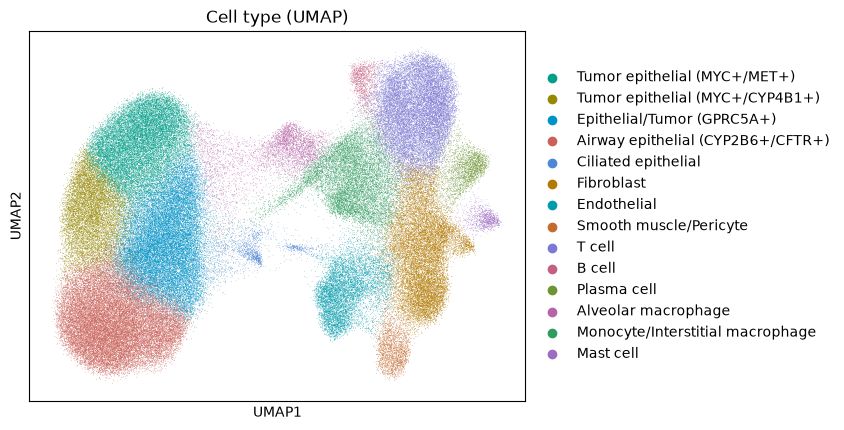

In [31]:
# UMAP에 세포유형을 색칠하여 클러스터 분리도 대비 세포유형 라벨이 타당한지 확인
sc.pl.umap(adata, color="cell_type", palette=CELL_TYPE_PALETTE, title="Cell type (UMAP)")

### 2-9. 공간 좌표에 세포유형 시각화

실제 조직 내 좌표(adata.obsm["spatial"])에 세포유형을 뿌려 폐 선암 조직의 공간 구조
(종양 영역, 기질/면역 침윤 패턴 등)를 확인한다.

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


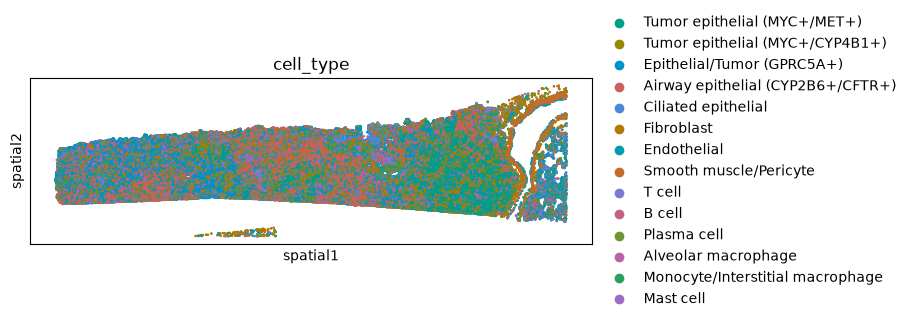

In [32]:
# palette 인자 없이 호출 -> adata.uns["cell_type_colors"]에 등록해둔 고정 팔레트를 자동으로 사용
sq.pl.spatial_scatter(
    adata,
    color="cell_type",
    shape=None,
    size=2,
    img=False,
    figsize=(9, 9),
)

### 2-10. 세포유형별 세포 수 및 비율

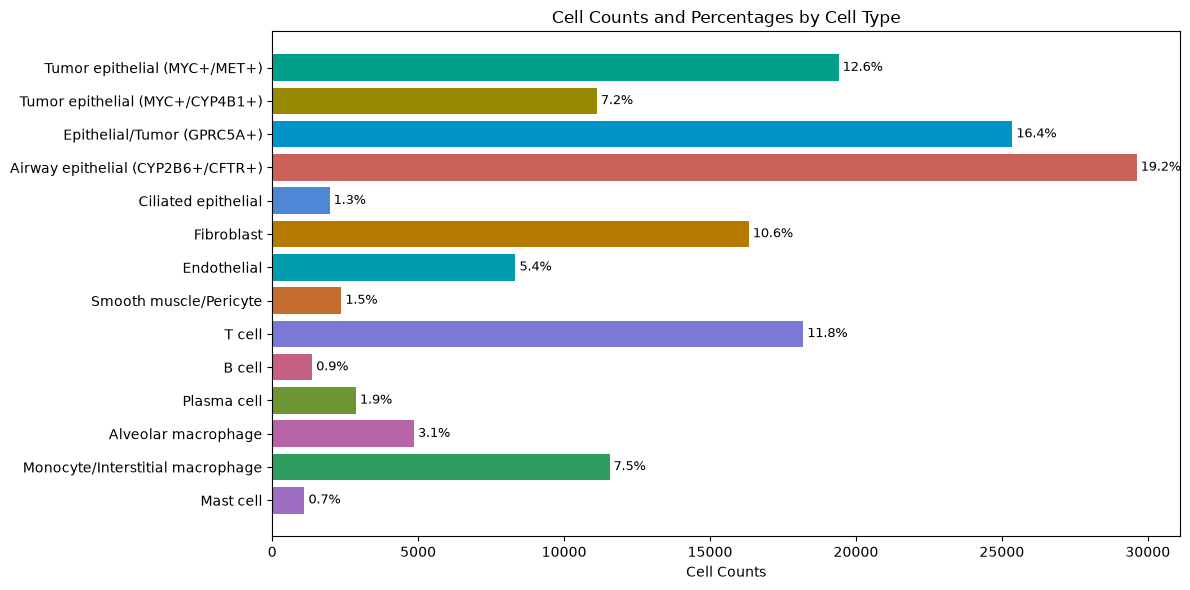

In [33]:
# 세포유형별 세포 수를 가로 막대그래프로 표시하고, 막대 끝에 전체 대비 비율(%)을 직접 라벨링한다.
cell_type_counts = adata.obs["cell_type"].value_counts().reindex(CELL_TYPE_ORDER)
cell_type_pct = 100 * cell_type_counts / cell_type_counts.sum()

fig, ax = plt.subplots(figsize=(12, 6))
order = cell_type_counts.index[::-1]  # 위에서부터 CELL_TYPE_ORDER 순서로 보이도록 역순 배치
bars = ax.barh(order, cell_type_counts.reindex(order), color=[CELL_TYPE_PALETTE[ct] for ct in order])
ax.set_xlabel("Cell Counts")
ax.set_title("Cell Counts and Percentages by Cell Type")
for bar, ct in zip(bars, order):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {cell_type_pct[ct]:.1f}%",
        va="center",
        fontsize=9,
    )
fig.tight_layout()
plt.show()

### 2-12. 세포유형의 공간적 조직화 확인을 위한 TME 구역(zone) 정의

14개 세포유형을 한 지도에 모두 겹쳐 그리면(2-9) 색이 너무 많아 공간 패턴을 읽기 어렵다.
종양 미세환경(TME) 구조 가설을 눈으로 확인하기 위해, 세포유형을 4개의 넓은 기능 구역으로
압축한다: 종양 추정 상피(Tumor-suspect epithelial) / 정상형 상피(Normal-like epithelium) /
면역(Immune) / 기질(Stroma). 이 구역화는 어디까지나 시각적 확인용이며, 실제 인접성/공존 여부에
대한 정량적 검증은 이후 5. Neighborhood Enrichment 단계(nhood_enrichment, co_occurrence)에서
수행한다.

In [34]:
# 세포유형 -> TME 구역(zone) 매핑. 종양 추정 상피 3종(7,8,10)과 정상형 상피 2종(9,11)을
# 각각 하나의 구역으로 묶어 공간 분리 여부를 바로 비교할 수 있게 한다.
TME_ZONE_MAP = {
    "Tumor epithelial (MYC+/MET+)": "Tumor-suspect epithelial",
    "Tumor epithelial (MYC+/CYP4B1+)": "Tumor-suspect epithelial",
    "Epithelial/Tumor (GPRC5A+)": "Tumor-suspect epithelial",
    "Airway epithelial (CYP2B6+/CFTR+)": "Normal-like epithelium",
    "Ciliated epithelial": "Normal-like epithelium",
    "T cell": "Immune",
    "B cell": "Immune",
    "Plasma cell": "Immune",
    "Alveolar macrophage": "Immune",
    "Monocyte/Interstitial macrophage": "Immune",
    "Mast cell": "Immune",
    "Fibroblast": "Stroma",
    "Endothelial": "Stroma",
    "Smooth muscle/Pericyte": "Stroma",
}
TME_ZONE_ORDER = ["Tumor-suspect epithelial", "Normal-like epithelium", "Immune", "Stroma"]
TME_ZONE_PALETTE = dict(zip(TME_ZONE_ORDER, ["#e34948", "#2a78d6", "#4a3aa7", "#1baf7a"]))

adata.obs["tme_zone"] = (
    adata.obs["cell_type"].map(TME_ZONE_MAP).astype("category").cat.reorder_categories(TME_ZONE_ORDER)
)
adata.uns["tme_zone_colors"] = [TME_ZONE_PALETTE[z] for z in TME_ZONE_ORDER]
adata.obs["tme_zone"].value_counts()

tme_zone
Tumor-suspect epithelial    55890
Immune                      39954
Normal-like epithelium      31591
Stroma                      27034
Name: count, dtype: int64

### 2-13. TME 구역 공간 개요

4개 구역만 색칠하면 2-9보다 훨씬 적은 색으로 종양/정상/면역/기질 영역이 뭉쳐 있는지 한눈에 볼 수 있다.

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


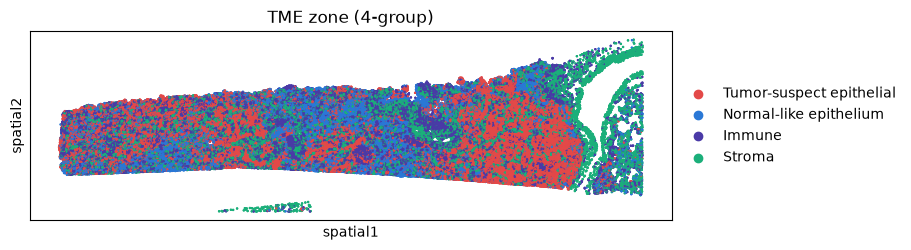

In [35]:
sq.pl.spatial_scatter(
    adata,
    color="tme_zone",
    shape=None,
    size=2,
    img=False,
    figsize=(9, 9),
    title="TME zone (4-group)",
)

### 2-14. Annotation 검증: 종양 추정 상피 vs 정상형 상피(9·11번) 공간 분리 확인

클러스터 7·8·10(Tumor-suspect epithelial)과 9·11(Normal-like epithelium)만 색칠하고 나머지는
회색으로 지워서, 두 구역이 서로 다른 영역에 존재하는지(=annotation이 타당한지) 직접 대조한다.
같은 영역에 뒤섞여 있다면 앞서 2-6에서 내린 "종양 vs 정상" 구분이 재검토가 필요하다는 신호다.

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


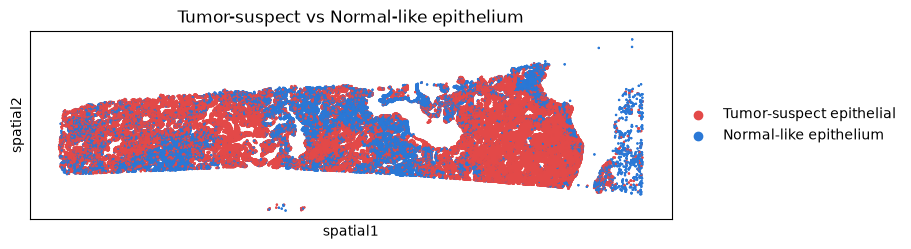

In [36]:
sq.pl.spatial_scatter(
    adata,
    color="tme_zone",
    groups=["Tumor-suspect epithelial", "Normal-like epithelium"],
    na_color="whitesmoke",
    shape=None,
    size=2,
    img=False,
    figsize=(9, 9),
    title="Tumor-suspect vs Normal-like epithelium",
)

### 2-15. 구역별 개별 하이라이트 (종양 경계의 면역/기질 분포)

구역을 하나씩 켜고 나머지를 회색으로 지워서, 종양 추정 상피가 뭉친 영역의 경계에 면역세포가
분포하는지, 기질(섬유아세포/내피/평활근·주피세포)이 별도의 구획을 이루는지 확인한다.

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


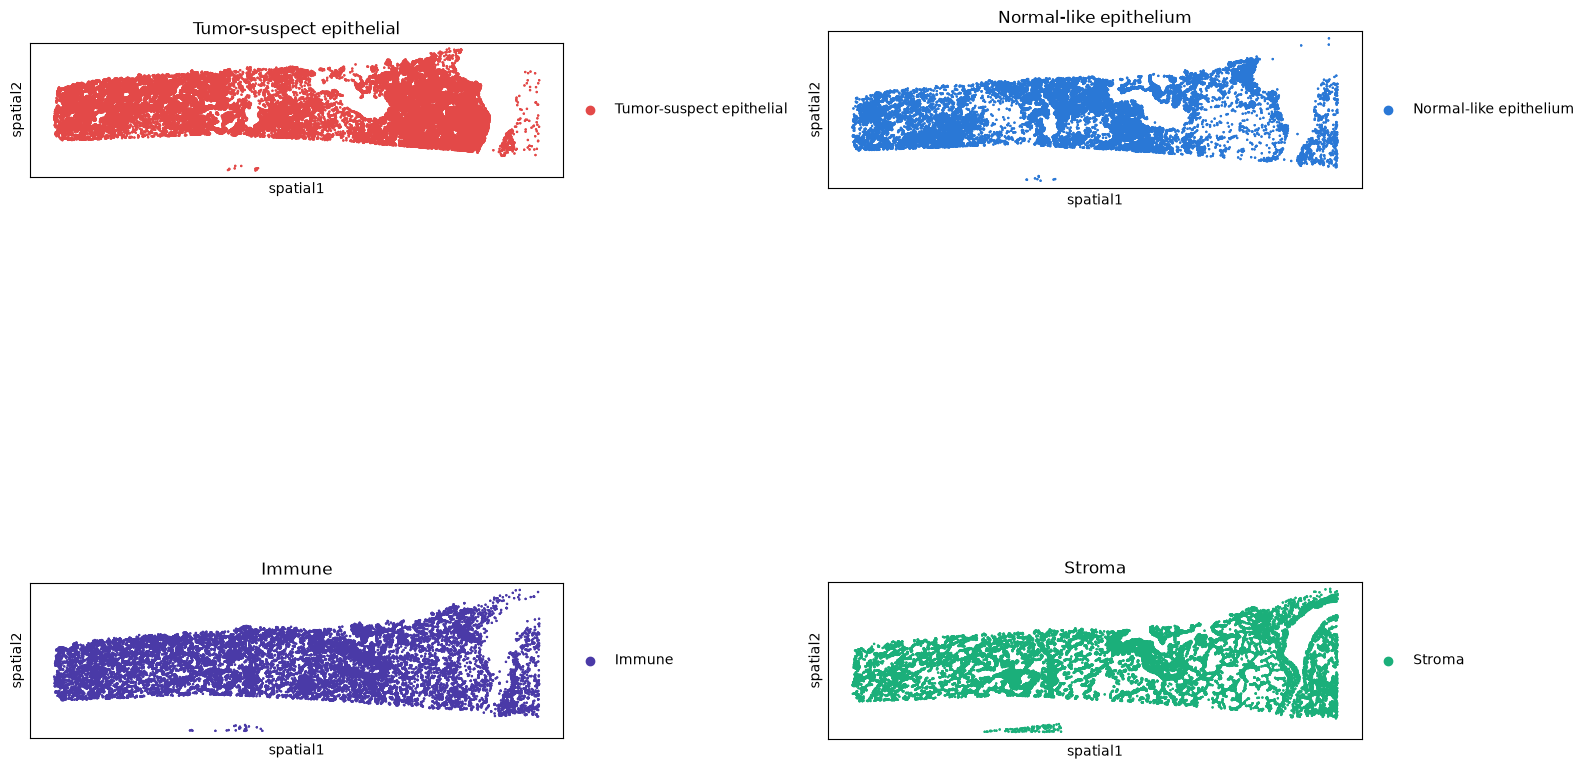

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, zone in zip(axes.ravel(), TME_ZONE_ORDER):
    sq.pl.spatial_scatter(
        adata,
        color="tme_zone",
        groups=[zone],
        na_color="lightgray",
        shape=None,
        size=2,
        img=False,
        ax=ax,
        title=zone,
    )
fig.tight_layout()
plt.show()

### 2-16. Annotation 완료 상태 저장

이후 단계(Ligand-Receptor, Niche, Neighborhood)에서 다시 불러올 수 있도록 `cell_type`,
`tme_zone`까지 반영된 AnnData를 h5ad로 저장한다.

In [38]:
adata.write("/data2/projects/2025_heartfailure/spatial_tme/xenium_lung/adata_annotated.h5ad")

### 2-17. (재실행용) 저장된 AnnData 다시 불러오기

커널을 재시작했거나 Ligand-Receptor/Niche/Neighborhood 단계만 따로 다시 실행할 때는,
QC/Annotation 과정을 처음부터 다시 돌릴 필요 없이 위 2-16에서 저장한 h5ad를 다시 불러와
`adata`에 할당하면 된다.

In [39]:
# 2-16에서 저장한 h5ad를 다시 불러온다. cell_type, tme_zone 등 obs 컬럼과
# cell_type_colors, tme_zone_colors 등 uns 팔레트까지 그대로 복원된다.
adata = sc.read_h5ad("/data2/projects/2025_heartfailure/spatial_tme/xenium_lung/adata_annotated.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 154469 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'leiden', 'cell_type', 'tme_zone'
    var: 'gene_ids', 'feature_types', 'genome', 'is_gene', 'is_neg_control_probe', 'is_neg_control_codeword', 'is_unassigned_codeword', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatialdata_attrs', 'tme_zone_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


In [40]:
# (참고) 위 2-1~2-16의 인라인 로직을 이후 src/annotation.py 모듈 함수로 리팩터링할 때
# 쓸 자리표시자. 현재는 위 인라인 코드가 실제 분석 로직이며, 아래는 실행되지 않는다.
# marker_dict = {...}
# adata = annotation.run_leiden_clustering(adata)
# adata = annotation.score_marker_genes(adata, marker_dict)
# adata = annotation.annotate_cell_types(adata, marker_dict)

## 3. Neighborhood Enrichment / Co-occurrence

### 3-1. 공간 이웃 그래프 구축 (Delaunay triangulation)

Xenium은 Visium처럼 고정 격자(grid) 위에 스팟이 놓인 데이터가 아니라, 세포마다 위치·밀도가
불균일한 단일세포 해상도 데이터다. 이런 경우 KNN(고정 k)이나 고정 radius보다 Delaunay
triangulation이 지역 세포 밀도에 자동으로 적응하는 그래프를 만들어준다는 점에서 더 적합하다
(squidpy 공식 Xenium 튜토리얼도 이 방식을 사용).

다만 Delaunay는 조직 경계·구멍(hole) 근처에서 비정상적으로 긴 엣지를 만드는 단점이 있다.
`spatial_neighbors_delaunay`의 `percentile` 인자로 삼각분할 결과는 그대로 두고 상위 1%
(99 percentile 초과) 길이의 엣지만 사후에 잘라내어 이 문제를 완화한다.

예상 소요 시간(154,469 세포, generic 좌표 기준 실측): 약 1~2초, 평균 degree ≈ 6.

In [43]:
# Delaunay triangulation 기반 공간 이웃 그래프. percentile=99로 상위 1% 길이의
# (조직 경계에서 생기는) 스퓨리어스한 긴 엣지를 사후 제거한다.
# 예상 소요 시간: 154,469 세포 규모에서 약 1~2초 (실측 기준, 가벼운 연산)
sq.gr.spatial_neighbors_delaunay(adata, percentile=99)

print("평균 이웃 수:", adata.obsp["spatial_connectivities"].nnz / adata.n_obs)

INFO     Creating graph using `None` transform and `1` libraries.                                                  
평균 이웃 수: 5.929603998213234


### 3-2. 세포유형 간 이웃 Enrichment (permutation test)

`cluster_key="cell_type"`(14종) 기준으로, 두 세포유형이 실제 공간 그래프에서 관측된 빈도만큼
서로 이웃하는지를 라벨을 섞은 permutation과 비교해 z-score로 계산한다. z-score가 높으면
서로 뭉쳐 있는(끌림) 관계, 낮으면 서로 피하는(배제) 관계다.

예상 소요 시간(154,469 세포, n_perms=1000 기본값, 실측): 약 15~20초 (numba 병렬).

In [44]:
# 세포유형 간 이웃 enrichment 계산 (permutation test, n_perms 기본값 1000)
# 예상 소요 시간: 154,469 세포 규모에서 약 15~20초 (실측 기준)
sq.gr.nhood_enrichment(adata, cluster_key="cell_type", seed=0)

  0%|          | 0/1000 [00:00<?, ?/s]

### 3-3. 이웃 Enrichment 히트맵

z-score는 0을 기준으로 양(끌림)/음(배제)이 대칭적인 값이므로, diverging(파랑↔빨강, 중립 회색
중앙) 컬러맵을 0 대칭 스케일(vmin=-vmax, vmax=vmax)로 적용해 끌림/배제를 직관적으로 구분한다.

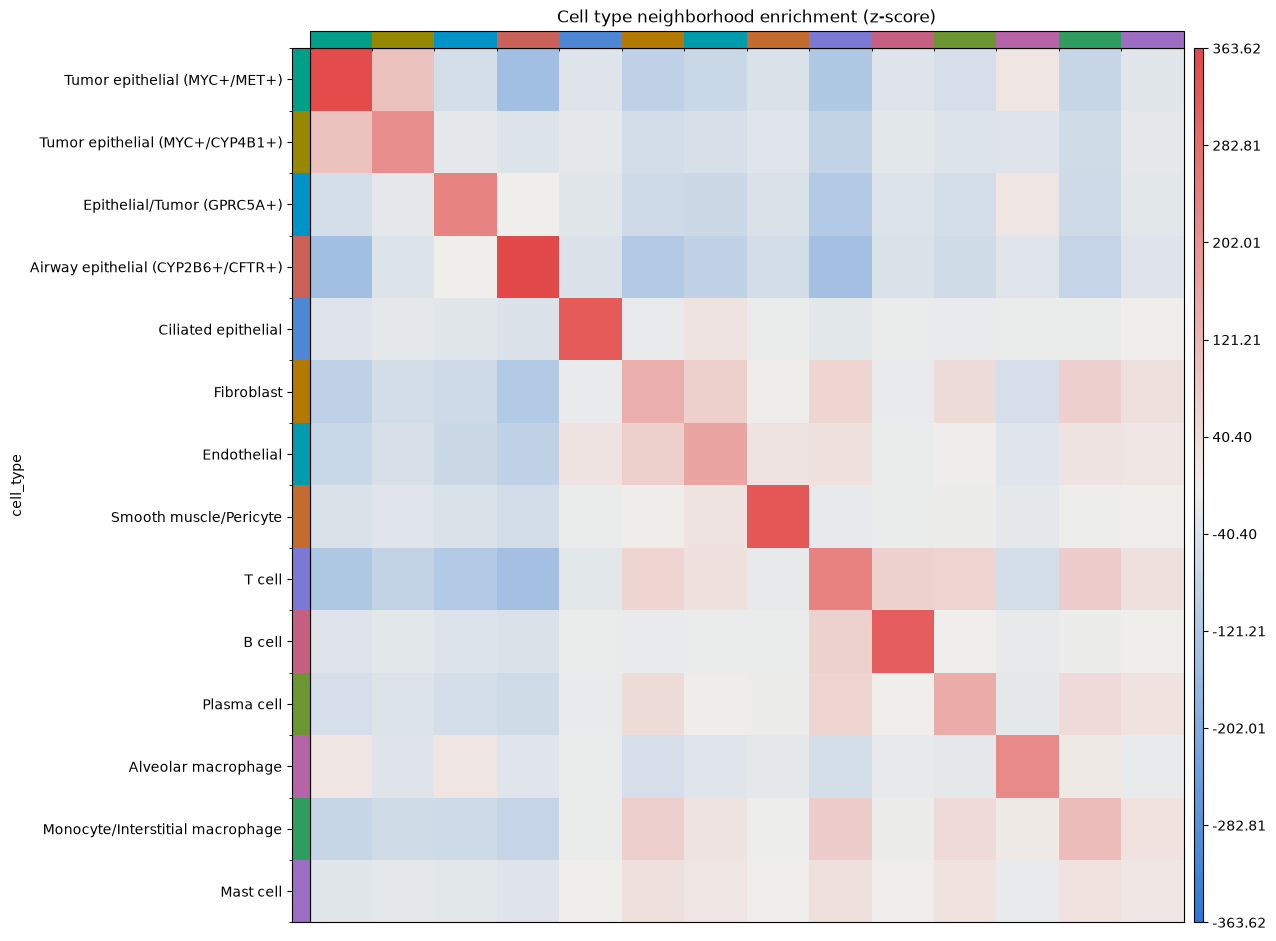

In [45]:
from matplotlib.colors import LinearSegmentedColormap

# diverging 팔레트(파랑 <-> 빨강, 중립 회색 중앙)를 z-score 0 대칭 스케일로 적용
diverging_cmap = LinearSegmentedColormap.from_list("blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"])
zscore = adata.uns["cell_type_nhood_enrichment"]["zscore"]
vmax = np.nanmax(np.abs(zscore))

sq.pl.nhood_enrichment(
    adata,
    cluster_key="cell_type",
    cmap=diverging_cmap,
    vmin=-vmax,
    vmax=vmax,
    figsize=(10, 9),
    title="Cell type neighborhood enrichment (z-score)",
)

### 3-4. 거리별 세포유형 동시출현(co-occurrence) 확률

`sq.gr.co_occurrence`는 모든 세포 쌍(i, j)에 대해 거리 구간마다 계산하는 O(N²) 알고리즘이라
15만 세포 규모에서는 비용이 크다. 기본값 `interval=50`(거리 구간 49개)을 쓰면 내부 카운트
배열과 연산량이 5배로 늘어나므로, `interval=10`(구간 9개)으로 줄여 관리 가능한 수준으로
맞춘다.

예상 소요 시간(154,469 세포, 14개 cell_type, interval=10, 실측): 가벼운 부하에서 약 20~25초.

⚠️ 이 서버는 여러 연구자가 함께 쓰는 공유 서버이고, `co_occurrence`는 all-pair 계산이라 CPU를
모두 사용한다. 다른 사용자의 학습 작업 등으로 부하가 몰리면(실측 중 load average가 높을 때
동일 설정으로 2분 넘게 걸린 사례 있음) 훨씬 오래 걸릴 수 있다. 너무 오래 걸리면 `interval`을
더 줄이거나(예: 5) 서버가 한가할 때 다시 실행한다.

**거리 축 단위 확인**: `adata.obsm["spatial"]`은 Xenium 세포 중심좌표이며, 평균 `cell_area`
(~74.5 µm², 세포 지름 환산 시 ~10 µm 규모로 정상 범위)와 일치해 물리 단위가 µm임을 확인했다.
이 섹션의 조직 범위는 x축 약 10.7 mm, y축 약 3.2 mm다. `co_occurrence`는 `interval`을 정수로
주면 가장 먼 두 점 사이 거리(대략 데이터 대각선의 절반, 이 데이터는 ~5.4 mm)까지 균등 분할하므로
`interval=10`에서는 구간 폭이 약 593 µm(세포 수십 개 폭)나 된다. 즉 첫 구간부터 이미 종양 경계
근처의 세포~소구획 스케일(수십 µm) 국소 배제 패턴보다 훨씬 넓은 스케일이라는 뜻이며, 이 점을
감안하지 않으면 아래 5-5의 "가까운 거리"라는 표현을 세포 단위 근접성으로 오해하기 쉽다. 더 촘촘한
근거리 해상도가 필요하면 `interval`에 정수 대신 명시적 거리 배열(예: 0~500 µm 구간을 촘촘히 나눈
뒤 나머지를 성기게)을 전달해야 한다. 아래 계산 직후 셀에서 실제 구간 경계를 출력해 확인한다.

In [46]:
# 거리 구간별 세포유형 동시출현 확률 계산 (O(N^2), interval을 줄여 연산량 관리)
# 예상 소요 시간: 154,469 세포 규모에서 interval=10 기준 약 20~25초 (가벼운 부하일 때, 실측 기준)
sq.gr.co_occurrence(adata, cluster_key="cell_type", interval=10)

In [ ]:
# 실제 계산된 거리 구간 경계 확인 (5-4에서 예상한 스케일이 맞는지 검증)
co_occ_interval = adata.uns["cell_type_co_occurrence"]["interval"]
print("구간 경계(µm):", np.round(co_occ_interval, 1))
print("구간 경계(mm):", np.round(co_occ_interval / 1000, 3))
print("구간 폭(µm):", np.round(np.diff(co_occ_interval), 1))

### 3-5. 종양 추정 상피 기준 동시출현 곡선

종양 추정 상피 3종(클러스터 7·8·10)을 각각 기준(reference)으로 놓고, 거리가 멀어질수록
다른 세포유형과의 동시출현 확률비가 어떻게 변하는지 확인한다. 비율이 1보다 크면 해당 거리에서
기준 세포유형과 더 자주 같이 있다는 뜻이고, 1보다 작으면 그 거리에서는 서로 덜 같이 있다는
뜻이다(가까운 거리에서 1보다 큰 세포유형이 곧 종양 경계에 인접해 있는 세포유형 후보).

⚠️ 해석 시 유의점 2가지.
1. **거리 스케일**: 5-4에서 확인했듯 이 `interval` 설정의 첫 구간 자체가 이미 ~593 µm 폭이다.
   따라서 여기서 "가까운 거리"는 세포 몇 개 폭이 아니라 수십~수백 개 세포가 포함되는
   소구획(niche) 스케일의 근접성을 의미하며, 단일 세포 단위의 미세한 배제 패턴까지는
   이 해상도로 구분할 수 없다.
2. **관찰 범위의 한정**: 아래에서 관찰되는 패턴(예: 종양 코어 주변 특정 세포유형의 배제
   경향)은 이 폐 선암 조직 1개 Xenium 섹션에서 나온 결과다. 다른 환자·부위·섹션에도
   동일하게 적용되는 일반화된 결론이 아니라, "이 섹션에서 관찰된 패턴"으로 한정해서
   서술한다.

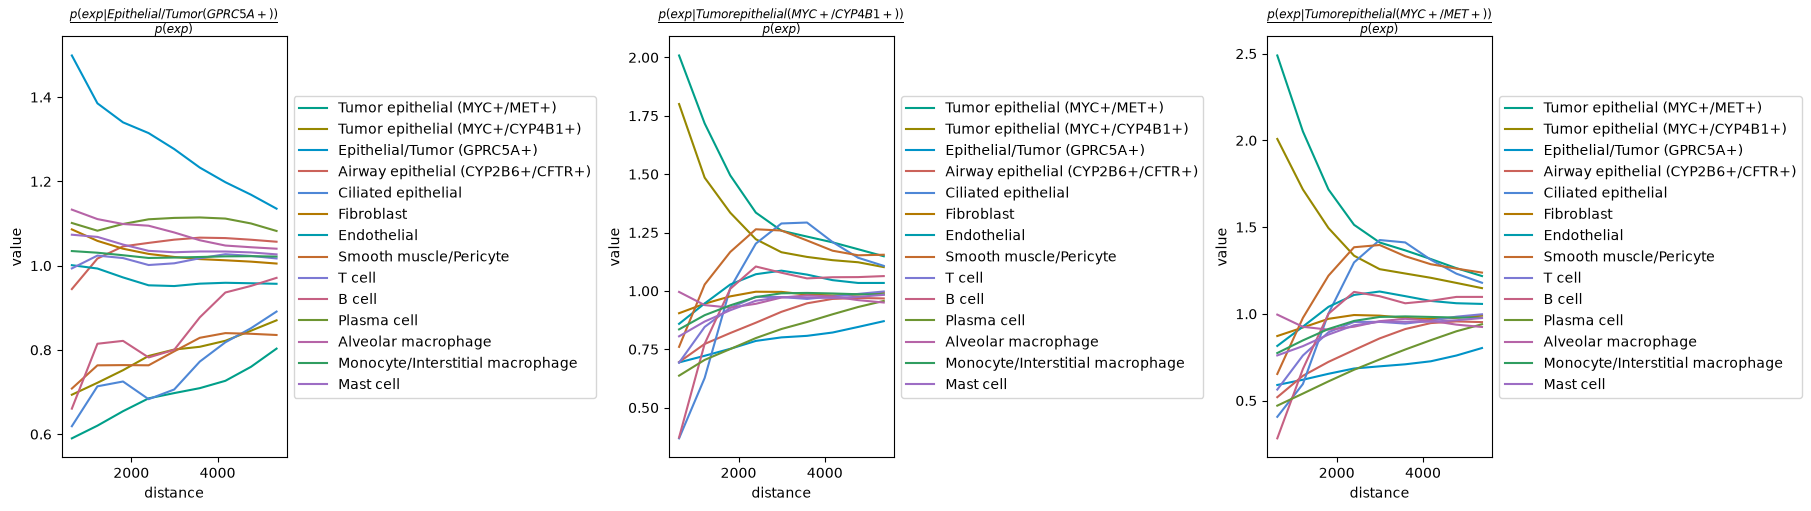

In [47]:
TUMOR_SUSPECT_TYPES = [
    "Tumor epithelial (MYC+/MET+)",
    "Tumor epithelial (MYC+/CYP4B1+)",
    "Epithelial/Tumor (GPRC5A+)",
]

sq.pl.co_occurrence(
    adata,
    cluster_key="cell_type",
    clusters=TUMOR_SUSPECT_TYPES,
    figsize=(18, 5),
)

### 3-6. 근거리 해상도를 높인 명시적 거리 구간으로 재계산

5-4에서 확인했듯 `interval=10`(정수) 방식은 첫 구간부터 이미 ~593 µm라 근거리(수십~수백 µm)
해상도가 부족하다. 종양 코어 주변 림프구 배제/침윤 패턴처럼 세포 몇~수십 개 폭에서 벌어지는
현상을 보려면 근거리 구간을 훨씬 촘촘하게 잡아야 한다. 아래에서는 명시적 거리 배열
(0~200 µm: 20 µm 간격, 200 µm~1 mm: 100 µm 간격, 1~3 mm: 500 µm 간격)을 `interval`에
직접 전달해 재계산한다. 원거리(3 mm 초과)는 이 조직 y축 폭(~3.2 mm)에 근접하거나 넘어서는
스케일이라 절단했다.

⚠️ 구간 수가 늘수록(9구간 → 22구간, 약 2.4배) 계산 시간도 비례해서 늘어난다. 전체
154,469개 세포로 그대로 돌리면 수 분 단위까지 걸릴 수 있으므로, 아래 `RUN_ON_SUBSET`을
`True`(기본값)로 두면 이번 관심 대상인 종양 추정 상피 3종 + T/B/Plasma 림프구만 남긴
부분집합(전체의 약 절반, ~78,000개 세포)으로 계산해 O(N²) 비용을 대략 1/4 수준으로 줄인다.
단, 부분집합으로 돌리면 확률이 "포함된 세포유형들 사이"로만 정규화되므로(기질/내피 등
제외된 세포유형과의 상호작용이 빠짐) 절대값이 전체 데이터 기준과 달라질 수 있다 — 근거리
추세 확인용으로는 유효하지만, 전체 세포유형을 포함한 절대 수치가 필요하면 `RUN_ON_SUBSET=False`로
바꿔(더 오래 걸리더라도) 전체 데이터로 재실행한다.

In [49]:
# 근거리(0~200um)는 20um 간격, 중간(200um~1mm)은 100um 간격, 원거리(1~3mm)는 500um 간격인
# 명시적 거리 구간. 정수 interval(예: 10)의 ~593um짜리 첫 구간보다 근거리 해상도가 훨씬 높다.
COOC_INTERVAL = np.concatenate([
    np.arange(0, 200, 20),           # 0~180 um
    np.arange(200, 1000, 100),       # 200~900 um
    np.arange(1000, 3000 + 1, 500),  # 1000~3000 um
])
print(f"구간 개수: {len(COOC_INTERVAL) - 1}개, 범위: {COOC_INTERVAL.min()}~{COOC_INTERVAL.max()} um")

구간 개수: 22개, 범위: 0~3000 um


In [50]:
# 관심 세포유형(종양 추정 상피 3종 + T/B/Plasma 림프구)만 남긴 부분집합.
# RUN_ON_SUBSET=False로 바꾸면 전체 세포로 재계산한다(더 오래 걸림).
RUN_ON_SUBSET = True
LYMPHOCYTE_TYPES = ["T cell", "B cell", "Plasma cell"]
FOCUS_CELL_TYPES = TUMOR_SUSPECT_TYPES + LYMPHOCYTE_TYPES

if RUN_ON_SUBSET:
    adata_cooc = adata[adata.obs["cell_type"].isin(FOCUS_CELL_TYPES)].copy()
    adata_cooc.obs["cell_type"] = adata_cooc.obs["cell_type"].cat.remove_unused_categories()
    print(f"부분집합: {adata_cooc.n_obs}개 세포 (전체 {adata.n_obs}개 중 {adata_cooc.n_obs / adata.n_obs:.1%})")
else:
    adata_cooc = adata
    print(f"전체 데이터 사용: {adata_cooc.n_obs}개 세포")

부분집합: 78327개 세포 (전체 154469개 중 50.7%)


In [51]:
# 명시적 구간(22개 구간, 5-4의 9구간 대비 약 2.4배)으로 재계산.
# 예상 소요 시간: RUN_ON_SUBSET=True(~78,000 세포) 기준 5-4의 20~25초보다는 짧되 구간 수
# 증가분(~2.4배)이 있어 대략 10~20초 수준으로 추정된다(실측 필요).
# RUN_ON_SUBSET=False(전체 154,469 세포)로 돌리면 N^2 비용 증가와 구간 수 증가가 겹쳐
# 수 분 단위로 늘어날 수 있다.
sq.gr.co_occurrence(adata_cooc, cluster_key="cell_type", interval=COOC_INTERVAL)

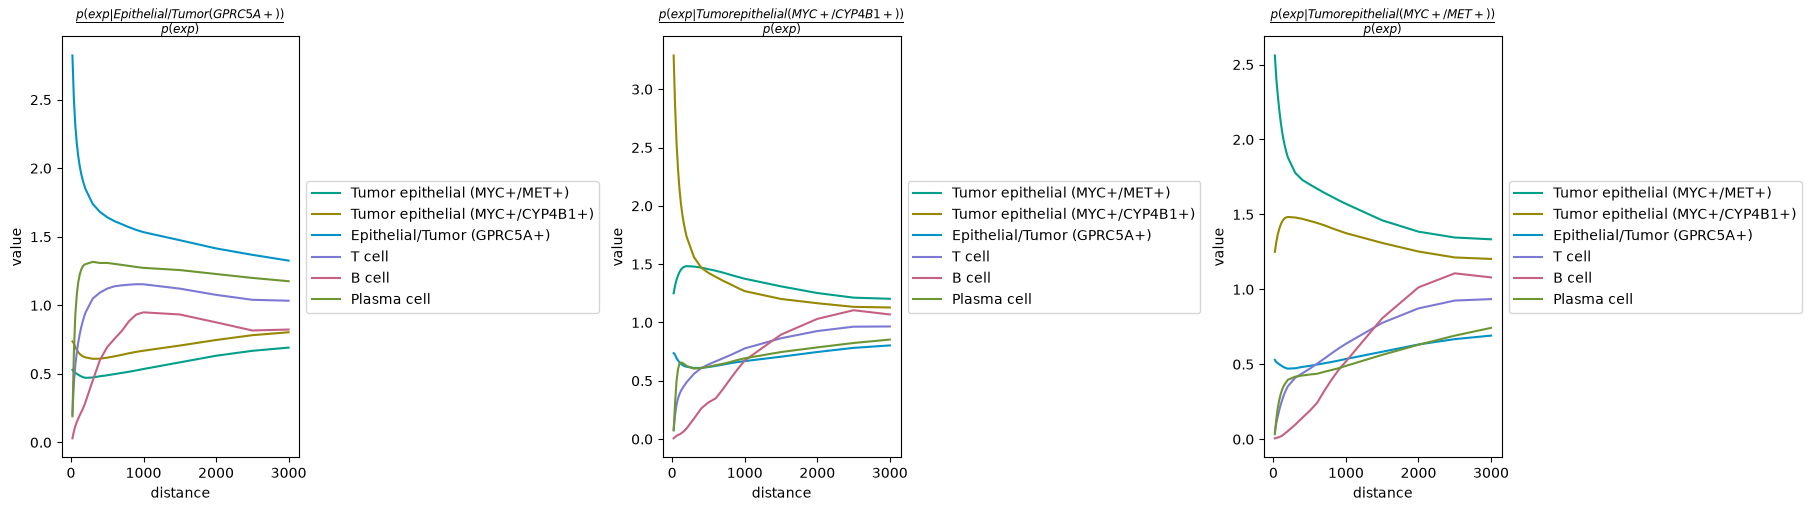

In [52]:
# 종양 추정 상피 3종을 기준(reference)으로 전체 구간(0~3mm) 곡선을 다시 그린다.
sq.pl.co_occurrence(
    adata_cooc,
    cluster_key="cell_type",
    clusters=TUMOR_SUSPECT_TYPES,
    figsize=(18, 5),
)

### 3-7. 근거리(0~200 µm) 구간 확대: T/B/Plasma 림프구 강조

위 3-6 전체 범위(0~3mm) 곡선은 near-field 변화가 촘촘히 겹쳐 잘 보이지 않는다. 동일한
계산 결과에서 0~200 µm 구간만 잘라내고, T/B/Plasma 림프구 3종만 색으로 강조(나머지는 옅은
회색 배경선)해 종양 코어 바로 주변에서 림프구 동시출현 비율이 거리에 따라 어떻게 변하는지
확인한다. 이 결과 역시 3-5에서 언급한 두 가지 유의점(거리 스케일 해석, 단일 섹션 한정
관찰)이 그대로 적용된다.

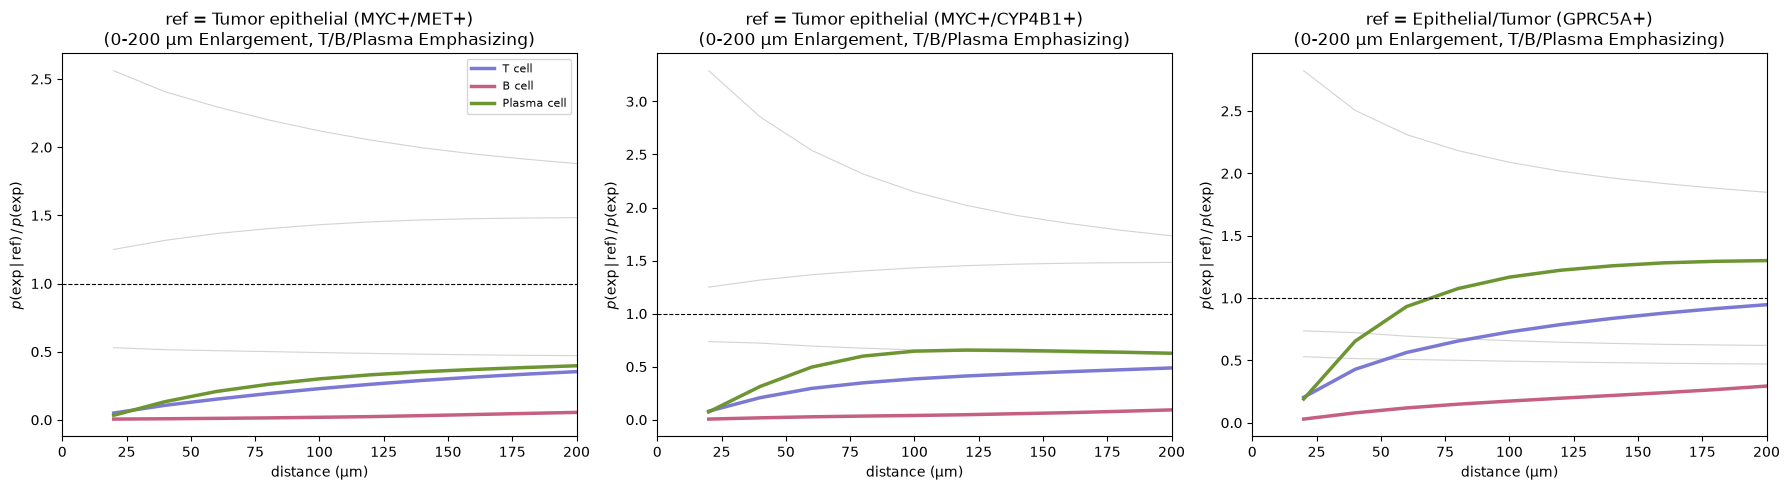

In [54]:
# 위와 동일한 co_occurrence 결과에서 0~200um 근거리 구간만 확대하고, T/B/Plasma 림프구
# 곡선만 강조한다(나머지 세포유형은 배경 참고용으로 옅은 회색 처리).
occ = adata_cooc.uns["cell_type_co_occurrence"]["occ"]
cooc_interval_used = adata_cooc.uns["cell_type_co_occurrence"]["interval"][1:]
categories = adata_cooc.obs["cell_type"].cat.categories
zoom_mask = cooc_interval_used <= 200

fig, axes = plt.subplots(1, len(TUMOR_SUSPECT_TYPES), figsize=(18, 5), sharey=False)
for ax, ref in zip(axes, TUMOR_SUSPECT_TYPES):
    ref_idx = categories.get_loc(ref)
    x = cooc_interval_used[zoom_mask]
    for c_idx, ct in enumerate(categories):
        y = occ[ref_idx, c_idx, :][zoom_mask]
        if ct in LYMPHOCYTE_TYPES:
            ax.plot(x, y, label=ct, color=CELL_TYPE_PALETTE[ct], linewidth=2.5)
        else:
            ax.plot(x, y, color="lightgray", linewidth=0.8, zorder=0)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xlim(0, 200)
    ax.set_xlabel("distance (µm)")
    ax.set_ylabel(r"$p(\mathrm{exp}\,|\,\mathrm{ref})\,/\,p(\mathrm{exp})$")
    ax.set_title(f"ref = {ref}\n(0-200 µm Enlargement, T/B/Plasma Emphasizing)")
axes[0].legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

### 3-8. 체크포인트 저장

여기까지의 `adata`(`leiden`, `cell_type`, `tme_zone`, `cell_type_nhood_enrichment`,
3-4의 정수 `interval=10` 기준 `cell_type_co_occurrence` 등)를 별도 파일로 저장한다.
단, 3-6/3-7에서 계산한 근거리 고해상도 co-occurrence 결과는 부분집합
`adata_cooc.uns`에 있어 이 체크포인트에는 포함되지 않는다.

In [55]:
adata.write("/data2/projects/2025_heartfailure/spatial_tme/xenium_lung/adata_cooccur.h5ad")

## 4. Ligand-Receptor Interaction

### 4-1. 분석 목적

`sq.gr.ligrec`(CellPhoneDB 방식 permutation test, 인터랙션 DB는 OmniPath에서 조회)으로
`cell_type`(14종) 간 리간드-수용체 상호작용을 본다. 관심 초점은 두 방향이다.

1. **종양 → 림프구**: 종양 추정 상피 3종(MYC+/MET+, MYC+/CYP4B1+, GPRC5A+)을 리간드 발현
   쪽(sender)으로, T/B/Plasma 림프구를 수용체 쪽(receiver)으로 두고 종양이 면역세포에
   보내는 신호를 확인한다.
2. **종양 ↔ 기질(Fibroblast·Endothelial)**: 종양 경계에 인접할 가능성이 있는 기질세포와
   종양 상피 사이의 상호작용을 양방향으로 확인한다.

`clusters=` 파라미터에 관심 있는 (sender, receiver) 방향쌍만 명시적으로 넘겨서(전체
14×14=196쌍이 아니라 21쌍만) 계산량을 줄인다. `adata.X`는 이미 정규화·log1p된 값이고
raw count는 `layers["counts"]`에 있으므로, `use_raw=False`로 현재 `adata.X`(log1p 발현)를
사용한다(`adata.raw`가 설정되어 있지 않아 `use_raw=True`면 에러가 난다).

In [56]:
# 관심 세포유형만 남긴 부분집합. 전체 154,469개 세포로 그대로 돌려도 되지만(ligrec은
# co_occurrence와 달리 세포 수보다 유전자 수·permutation 횟수가 주 비용이라 속도 차이는
# 크지 않다 - 실측 시 부분집합/전체 데이터 모두 21쌍·n_perms=1000 기준 약 40~45초로 비슷하다),
# 관심 대상만 남기면 메모리 사용량과 결과 해석이 더 명확해진다.
# RUN_ON_SUBSET=False로 바꾸면 전체 세포로 재계산한다.
RUN_ON_SUBSET = True

TUMOR_SUSPECT_TYPES = [
    "Tumor epithelial (MYC+/MET+)",
    "Tumor epithelial (MYC+/CYP4B1+)",
    "Epithelial/Tumor (GPRC5A+)",
]
LYMPHOCYTE_TYPES = ["T cell", "B cell", "Plasma cell"]
STROMA_BOUNDARY_TYPES = ["Fibroblast", "Endothelial"]
FOCUS_CELL_TYPES = TUMOR_SUSPECT_TYPES + LYMPHOCYTE_TYPES + STROMA_BOUNDARY_TYPES

if RUN_ON_SUBSET:
    adata_lr = adata[adata.obs["cell_type"].isin(FOCUS_CELL_TYPES)].copy()
    adata_lr.obs["cell_type"] = adata_lr.obs["cell_type"].cat.remove_unused_categories()
    print(f"부분집합: {adata_lr.n_obs}개 세포 (전체 {adata.n_obs}개 중 {adata_lr.n_obs / adata.n_obs:.1%})")
else:
    adata_lr = adata
    print(f"전체 데이터 사용: {adata_lr.n_obs}개 세포")

부분집합: 102993개 세포 (전체 154469개 중 66.7%)


In [57]:
# (sender, receiver) 방향쌍만 명시적으로 구성 - 전체 14x14=196쌍이 아니라 관심 있는 21쌍만.
# 1) 종양 3종 -> T/B/Plasma 림프구 (종양이 면역세포에 보내는 신호, 9쌍)
# 2) 종양 3종 <-> Fibroblast/Endothelial (종양 경계 기질과의 양방향 상호작용, 12쌍)
LR_CLUSTER_PAIRS = (
    [(sender, receiver) for sender in TUMOR_SUSPECT_TYPES for receiver in LYMPHOCYTE_TYPES]
    + [(sender, receiver) for sender in TUMOR_SUSPECT_TYPES for receiver in STROMA_BOUNDARY_TYPES]
    + [(sender, receiver) for sender in STROMA_BOUNDARY_TYPES for receiver in TUMOR_SUSPECT_TYPES]
)
print(f"방향쌍 개수: {len(LR_CLUSTER_PAIRS)}")

방향쌍 개수: 21


In [58]:
# sq.gr.ligrec: CellPhoneDB 방식 permutation test. interactions=None이면 OmniPath에서
# 리간드-수용체 인터랙션 DB를 온라인으로 받아온다(최초 실행 시 다운로드로 ~10~15초 추가,
# 이후 로컬 캐시 사용). use_raw=False로 log1p 정규화된 adata.X를 사용한다
# (adata.raw가 설정되어 있지 않아 기본값 use_raw=True로 두면 에러가 난다).
# 예상 소요 시간: 21개 방향쌍, n_perms=1000 기준 실측 약 40~45초
# (부분집합/전체 데이터 모두 비슷 - ligrec 비용은 세포 수보다 유전자 수·permutation 횟수가 지배적).
sq.gr.ligrec(
    adata_lr,
    cluster_key="cell_type",
    clusters=LR_CLUSTER_PAIRS,
    use_raw=False,
    n_perms=1000,
    seed=0,
)

  0%|          | 0/1000 [00:00<?, ?permutation/s]

### 4-2. 종양 → 림프구 시각화

종양 추정 상피 3종을 sender, T/B/Plasma 림프구를 receiver로 두고 유의미한(permutation
p-value < 0.05) 리간드-수용체 쌍만 표시한다.

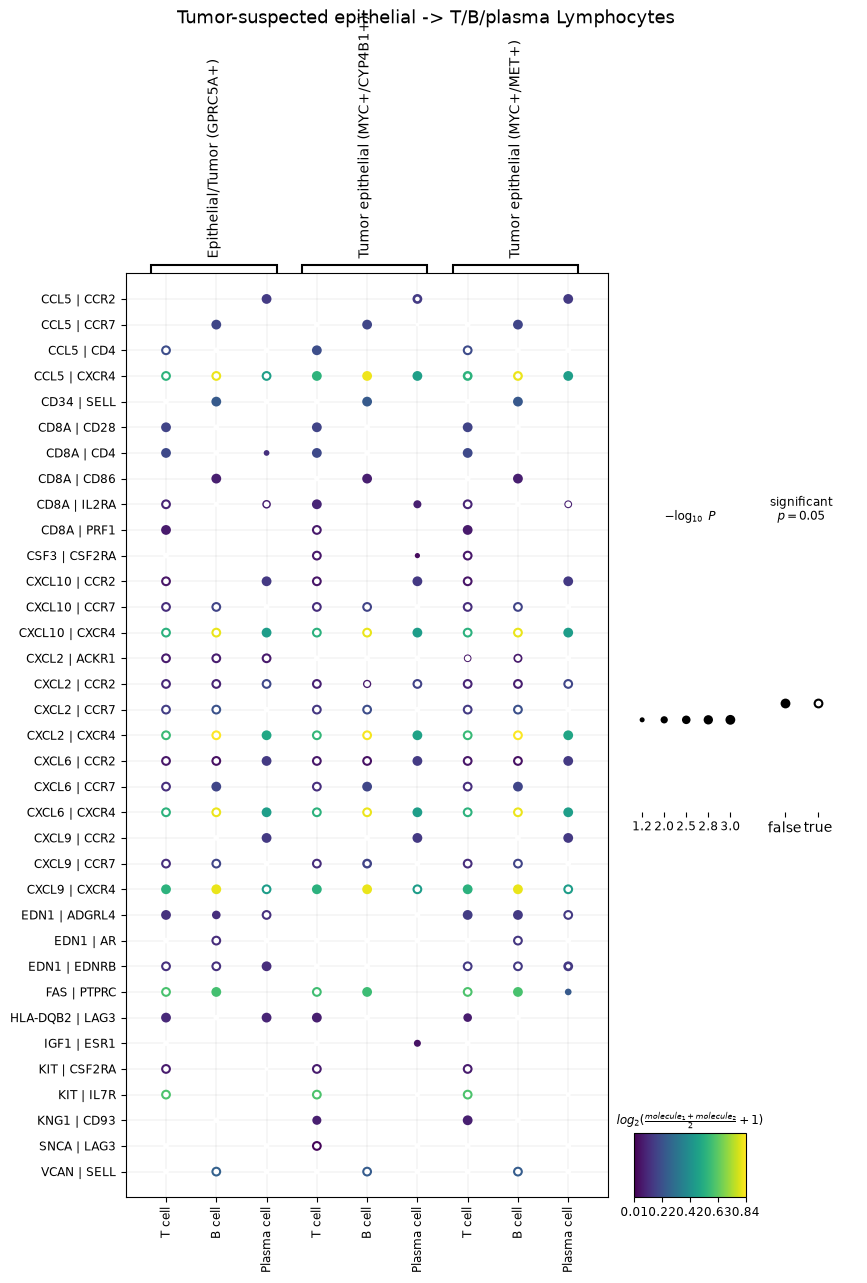

In [ ]:
sq.pl.ligrec(
    adata_lr,
    cluster_key="cell_type",
    source_groups=TUMOR_SUSPECT_TYPES,
    target_groups=LYMPHOCYTE_TYPES,
    pvalue_threshold=0.05,
    remove_nonsig_interactions=True,
    alpha=0.05,
    figsize=(8, 12),
    title="",
)
# sq.pl.ligrec의 title 인자는 컬럼 그룹 브라켓과 같은 줄(회전된 클러스터 라벨 바로 아래)에
# 그려져 라벨이 길면 겹친다. title=""로 내부 타이틀을 비우고 fig.suptitle로 맨 위에
# 별도로 붙여서 겹침을 피한다.
fig = plt.gcf()
fig.suptitle("Tumor-suspected epithelial -> T/B/plasma Lymphocytes", y=1.1, fontsize=13)

### 4-3. 종양 ↔ Fibroblast/Endothelial 시각화

종양 경계에 인접할 가능성이 있는 기질세포(Fibroblast, Endothelial)와 종양 추정 상피
사이의 양방향 상호작용을 같은 기준(p<0.05)으로 확인한다.

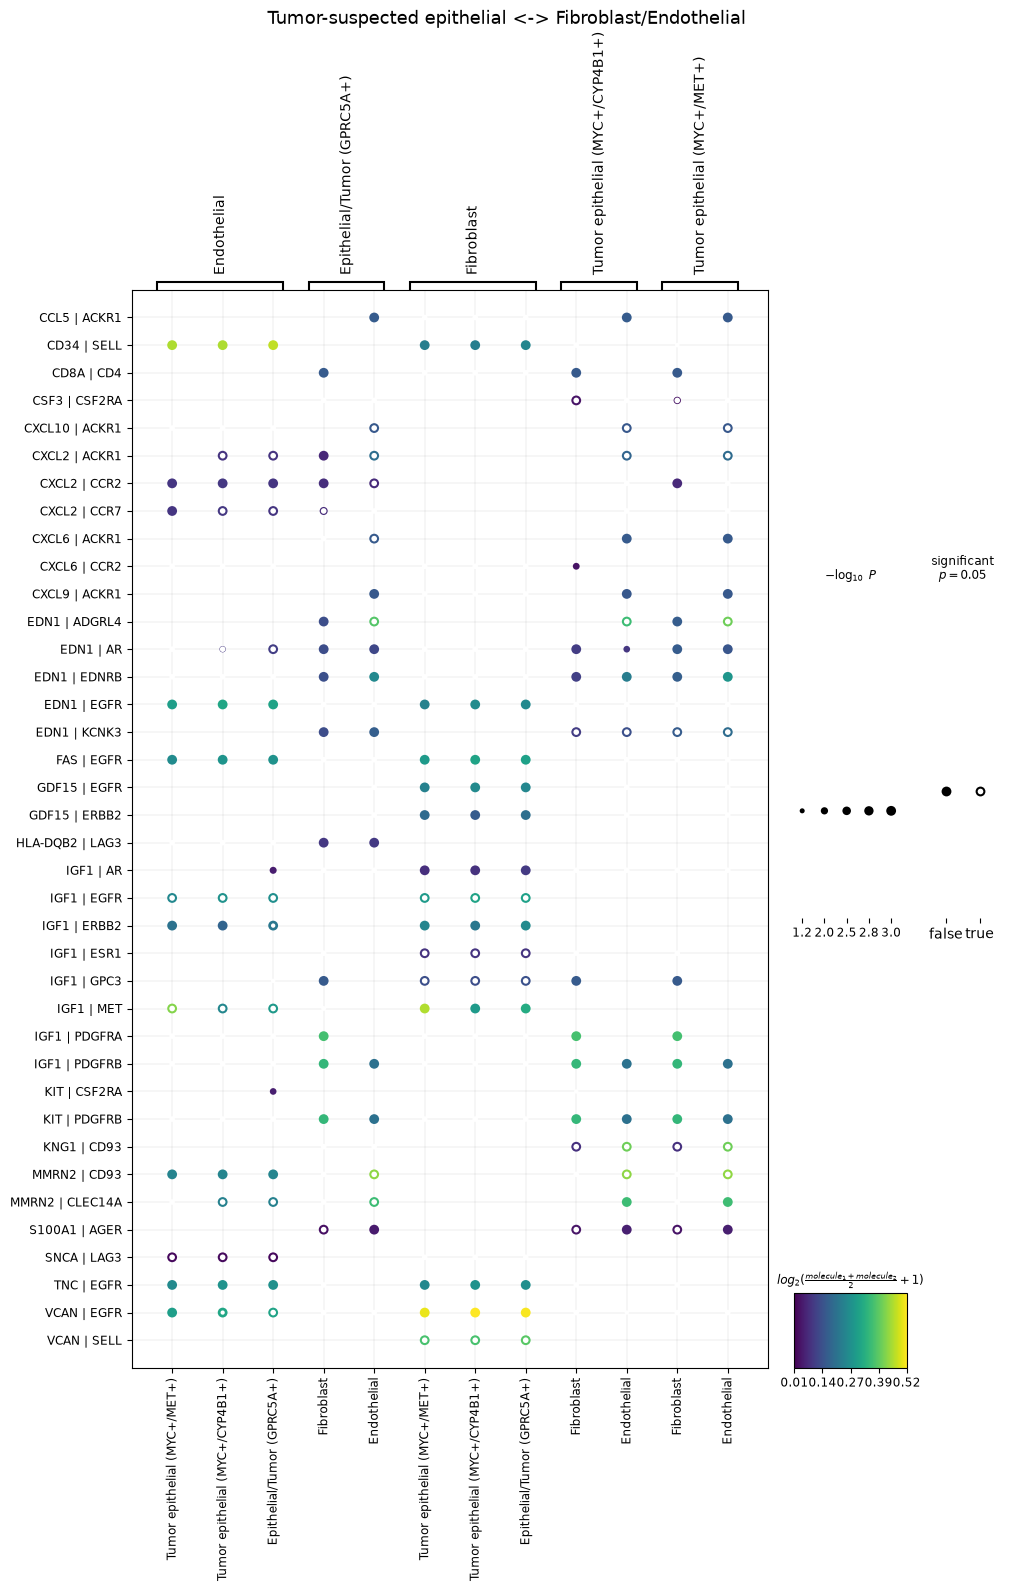

In [ ]:
sq.pl.ligrec(
    adata_lr,
    cluster_key="cell_type",
    source_groups=TUMOR_SUSPECT_TYPES + STROMA_BOUNDARY_TYPES,
    target_groups=TUMOR_SUSPECT_TYPES + STROMA_BOUNDARY_TYPES,
    pvalue_threshold=0.05,
    remove_nonsig_interactions=True,
    alpha=0.05,
    figsize=(10, 14),
    title="",
)
# 위와 동일한 이유로 title=""로 비우고 fig.suptitle로 대체한다.
fig = plt.gcf()
fig.suptitle("Tumor-suspected epithelial <-> Fibroblast/Endothelial", y=1.08, fontsize=13)

### 4-4. 유의미한 LR 쌍 상위 테이블

`means`/`pvalues`를 합쳐 유의미한(p<0.05) 쌍만 평균발현 내림차순으로 정리한다.

In [66]:
result = adata_lr.uns["cell_type_ligrec"]
means, pvalues = result["means"], result["pvalues"]

mean_long = means.stack(level=[0, 1], future_stack=True).rename("mean_expr")
pval_long = pvalues.stack(level=[0, 1], future_stack=True).rename("pvalue")
lr_table = pd.concat([mean_long, pval_long], axis=1).reset_index()
lr_table.columns = ["ligand", "receptor", "sender", "receiver", "mean_expr", "pvalue"]

N_TOP_LR = 30
top_lr = (
    lr_table[lr_table["pvalue"] < 0.05]
    .sort_values("mean_expr", ascending=False)
    .head(N_TOP_LR)
    .reset_index(drop=True)
)
print(f"유의미한(p<0.05) 쌍: {(lr_table['pvalue'] < 0.05).sum()}개 / 전체 {len(lr_table)}개")
top_lr

유의미한(p<0.05) 쌍: 343개 / 전체 1680개


,ligand,receptor,sender,receiver,mean_expr,pvalue
0,CXCL2,CXCR4,Epithelial/Tumor (GPRC5A+),B cell,0.790813,0.0
1,CXCL2,CXCR4,Tumor epithelial (MYC+/MET+),B cell,0.785741,0.0
2,CXCL2,CXCR4,Tumor epithelial (MYC+/CYP4B1+),B cell,0.777509,0.0
3,CCL5,CXCR4,Tumor epithelial (MYC+/CYP4B1+),B cell,0.762898,0.0
4,CCL5,CXCR4,Epithelial/Tumor (GPRC5A+),B cell,0.762653,0.0
5,CXCL6,CXCR4,Tumor epithelial (MYC+/CYP4B1+),B cell,0.761125,0.0
6,CXCL6,CXCR4,Tumor epithelial (MYC+/MET+),B cell,0.760242,0.0
7,CCL5,CXCR4,Tumor epithelial (MYC+/MET+),B cell,0.759831,0.0
8,CXCL6,CXCR4,Epithelial/Tumor (GPRC5A+),B cell,0.759078,0.0
9,CXCL9,CXCR4,Epithelial/Tumor (GPRC5A+),B cell,0.758714,0.0


### 4-5. 체크포인트 저장

여기까지의 `adata`(`cell_type`, `tme_zone` 등)를 별도 파일로 저장한다. 단,
`sq.gr.ligrec` 결과(`cell_type_ligrec`)는 부분집합 `adata_lr.uns`에 저장되어
있어 이 체크포인트에는 포함되지 않는다 — LR 결과를 이어서 쓰려면 `adata_lr`을
별도로 저장하거나, 이 셀 전에
`adata.uns["cell_type_ligrec"] = adata_lr.uns["cell_type_ligrec"]`로 옮겨
담아야 한다.

In [67]:
adata.write("/data2/projects/2025_heartfailure/spatial_tme/xenium_lung/adata_lrpair.h5ad")

## 5. Niche Definition

이 섹션은 아직 구현되지 않았다(README의 `향후 계획(Planned Extensions)` 참고).
`src/niche.py`의 `compute_cell_type_composition`/`define_niches`/
`assign_niche_labels`는 현재 스텁(`NotImplementedError`)이며, 아래 셀은 이후
채워 넣을 자리표시자다.

In [42]:
# (참고) Niche 정의가 구현되면 src/niche.py의 아래 함수들을 호출하게 될 자리표시자.
# 현재 src/niche.py는 스텁 상태(NotImplementedError)다.
# composition_df = niche.compute_cell_type_composition(adata, cluster_key="cell_type")
# niche_labels = niche.define_niches(composition_df, n_niches=10)
# adata = niche.assign_niche_labels(adata, niche_labels)